---

# Source: Data Storytelling & Interactive Dashboards.ipynb



## Section 0: Setup and Imports

Let us import all the libraries we will need for this session and configure Matplotlib to display plots inline.

In [2]:
# Configure Matplotlib for inline display in Jupyter
%matplotlib inline

# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Print version information
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("\nSetup complete!")

NumPy version: 2.4.4
Pandas version: 3.0.2
Matplotlib version: 3.10.8
Seaborn version: 0.13.2

Setup complete!


---

## Section 1: Why Visualization Matters — Anscombe's Quartet

### The Problem with Summary Statistics Alone

In 1973, statistician Francis Anscombe created four datasets with **identical summary statistics**:
- Same mean of x: 9.0
- Same mean of y: 7.5
- Same variance
- Same correlation: 0.816
- Same linear regression line: y = 3 + 0.5x

If you only looked at these statistics, you would conclude the four datasets are identical. But when visualized, they reveal completely different patterns.

This demonstrates why **you must visualize data** — summary statistics alone can deceive.

### Creating Anscombe's Four Datasets

Let us define all four datasets exactly as Anscombe published them.

In [3]:
# Dataset I: Simple linear relationship
x1 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y1 = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])

# Dataset II: Curved (quadratic) relationship
x2 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])

# Dataset III: Linear with one extreme outlier
x3 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y3 = np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])

# Dataset IV: All same x except one extreme point
x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8])
y4 = np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])

print("Anscombe's Quartet datasets created successfully.")

Anscombe's Quartet datasets created successfully.


### Computing Summary Statistics

Now let us compute the summary statistics for all four datasets to verify they are indeed identical.

In [4]:
datasets = [(x1, y1, "Dataset I"), (x2, y2, "Dataset II"),
            (x3, y3, "Dataset III"), (x4, y4, "Dataset IV")]

print("=== Anscombe's Quartet: Identical Statistics ===\n")
for x, y, name in datasets:
    print(f"{name}:")
    print(f"  Mean of x: {np.mean(x):.2f}")
    print(f"  Mean of y: {np.mean(y):.2f}")
    print(f"  Std of x:  {np.std(x, ddof=1):.2f}")
    print(f"  Std of y:  {np.std(y, ddof=1):.2f}")
    corr = np.corrcoef(x, y)[0, 1]
    print(f"  Correlation: {corr:.3f}")
    print()

=== Anscombe's Quartet: Identical Statistics ===

Dataset I:
  Mean of x: 9.00
  Mean of y: 7.50
  Std of x:  3.32
  Std of y:  2.03
  Correlation: 0.816

Dataset II:
  Mean of x: 9.00
  Mean of y: 7.50
  Std of x:  3.32
  Std of y:  2.03
  Correlation: 0.816

Dataset III:
  Mean of x: 9.00
  Mean of y: 7.50
  Std of x:  3.32
  Std of y:  2.03
  Correlation: 0.816

Dataset IV:
  Mean of x: 9.00
  Mean of y: 7.50
  Std of x:  3.32
  Std of y:  2.03
  Correlation: 0.817



### The Visual Reveal

Now we plot all four datasets on a 2x2 grid with their regression lines. This is where the truth emerges.

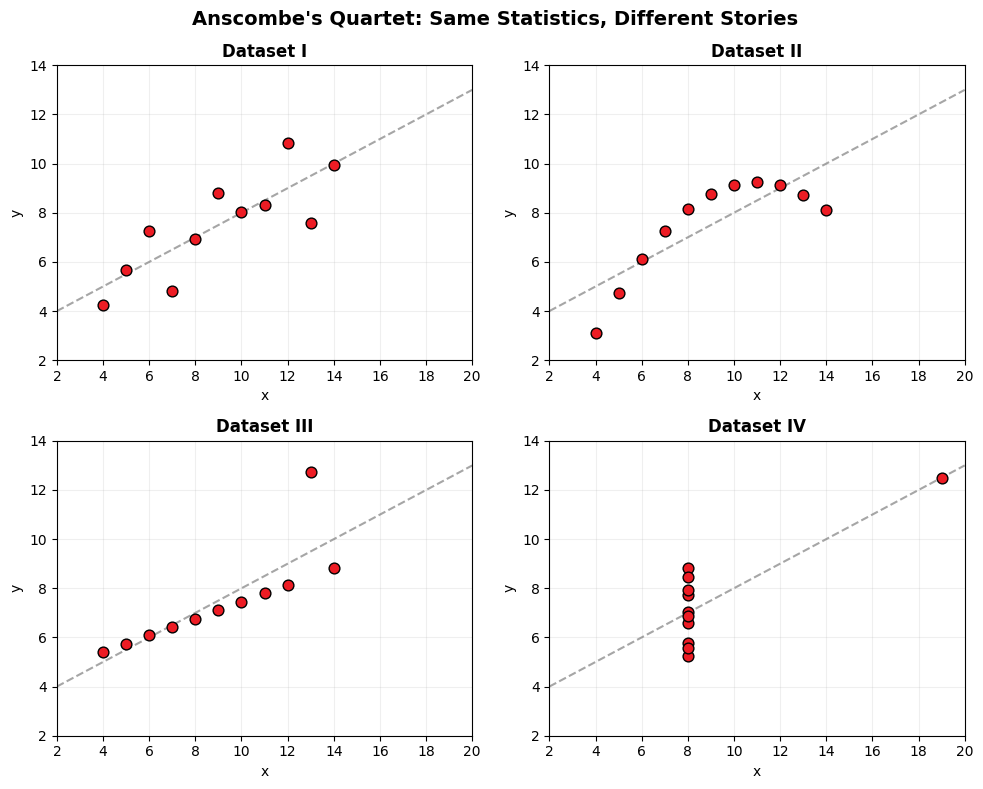

In [5]:
# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Anscombe's Quartet: Same Statistics, Different Stories",
             fontsize=14, fontweight='bold')

# Plot each dataset with its regression line
for ax, (x, y, name) in zip(axes.flat, datasets):
    # Scatter plot
    ax.scatter(x, y, color='#ED1C24', edgecolors='black', s=60, zorder=3)

    # Add regression line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(2, 20, 100)
    ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', alpha=0.7)

    # Labels and styling
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

### Key Takeaway

**Dataset I:** Clean linear relationship — exactly what the statistics predict.

**Dataset II:** Curved (parabolic) — fitting a straight line is the WRONG model.

**Dataset III:** Perfectly linear EXCEPT one outlier pulling the regression line.

**Dataset IV:** All points at x=8 except one extreme point at x=19 defining the entire slope.

**Lesson:** Summary statistics tell you PART of the truth. Visualization reveals the WHOLE truth.

---

## Section 2: Matplotlib Architecture — Figure, Axes, and Artists

### Understanding the Three-Layer Hierarchy

Matplotlib organizes charts into three layers:

1. **Figure** = The canvas (the entire window or image file)
2. **Axes** = One individual plot area (NOT "axis"!)
3. **Artist** = Every visual element (lines, bars, text, labels, ticks)

**Critical Distinction:** "Axes" (plural) is the plot container. "Axis" (singular) is the x or y scale.

### pyplot vs Object-Oriented Interface

Matplotlib offers two ways to create charts:

**pyplot (implicit state):** Quick and dirty for exploration
```python
plt.plot(x, y)
plt.title('My Chart')
```

**Object-Oriented (explicit control):** Professional, scalable, recommended
```python
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('My Chart')
```

We will use the Object-Oriented interface throughout this notebook.

### Demo: Same Chart, Two Approaches

Let us create identical charts using both approaches to see the difference.

In [6]:
# Sample data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue = [45000, 52000, 48000, 61000, 55000, 72000]

print("Sample data created: Monthly revenue for first 6 months")

Sample data created: Monthly revenue for first 6 months


### Approach 1: pyplot (implicit state)

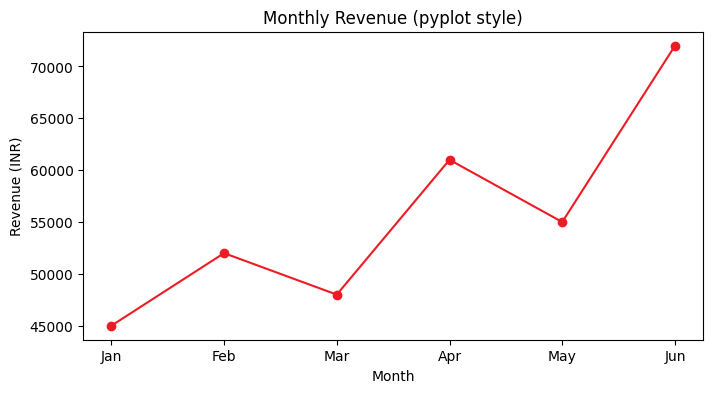

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(months, revenue, marker='o', color='#ED1C24')
plt.title('Monthly Revenue (pyplot style)')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.show()

In [8]:
months

['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

In [9]:
revenue

[45000, 52000, 48000, 61000, 55000, 72000]

### Approach 2: Object-Oriented (explicit control)

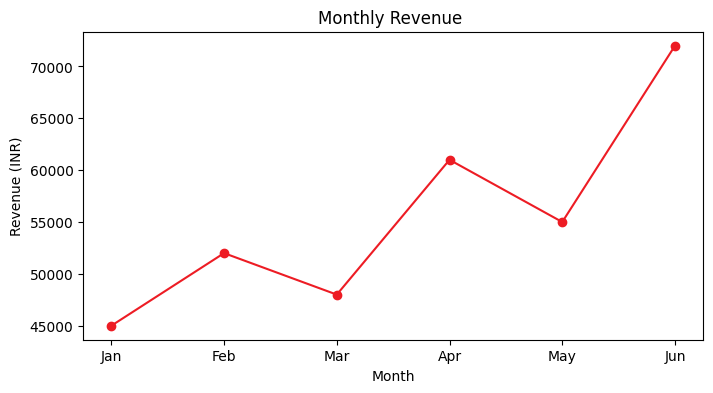

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(months, revenue, marker='o', color='#ED1C24')
ax.set_title('Monthly Revenue ')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (INR)')
plt.show()

### Multi-Panel Figures: Why OO Wins

The Object-Oriented interface shines when creating multiple plots on one canvas.

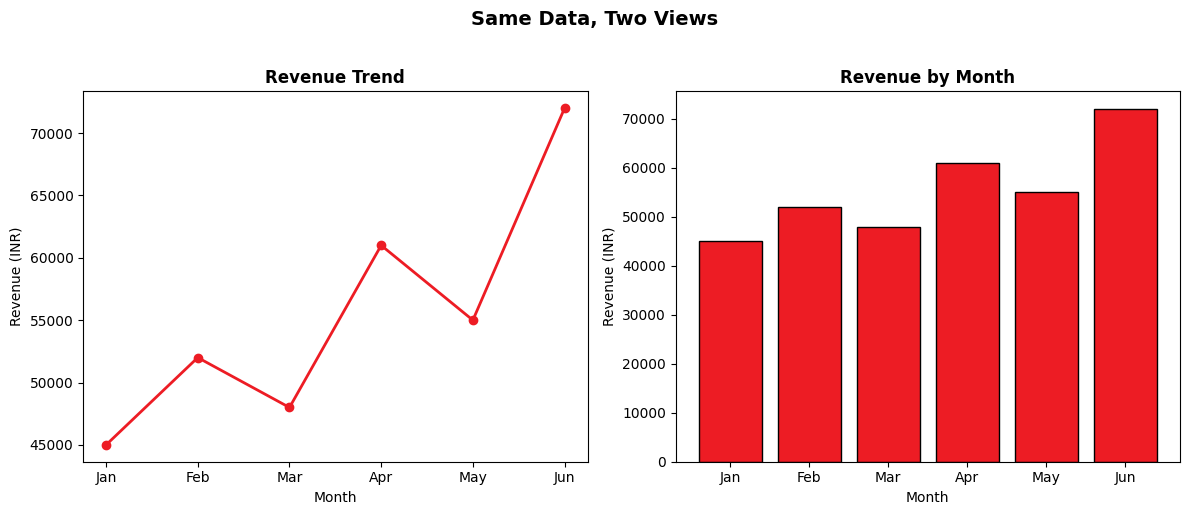

In [11]:
# Create one Figure with two Axes side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Line chart
axes[0].plot(months, revenue, marker='o', color='#ED1C24', linewidth=2)
axes[0].set_title('Revenue Trend', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (INR)')

# Right plot: Bar chart (same data, different visualization)
axes[1].bar(months, revenue, color='#ED1C24', edgecolor='black')
axes[1].set_title('Revenue by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (INR)')

# Overall title for the entire Figure
fig.suptitle('Same Data, Two Views', fontsize=14, fontweight='bold', y=1.02)

fig.tight_layout()
plt.show()

### Anatomy of a Plot: Every Element Named

Let us create a fully-labeled chart and identify every component.

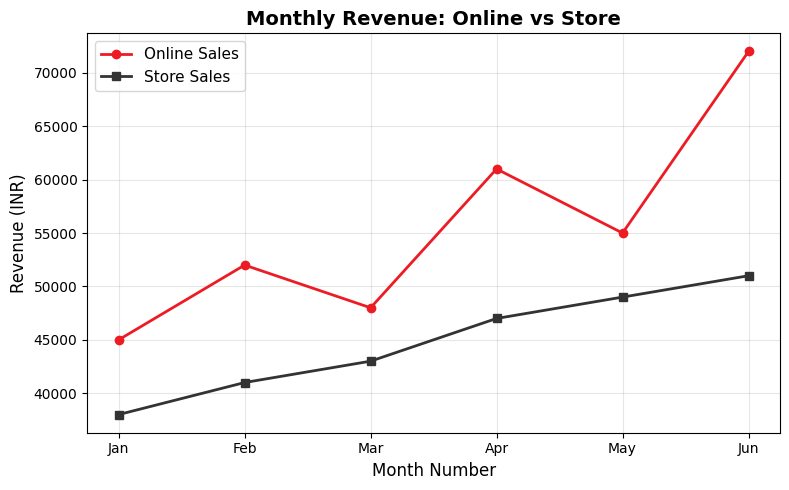

In [12]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(8, 5))

# Plot two lines to demonstrate legend
months_nums = range(1, 7)
online_revenue = [45000, 52000, 48000, 61000, 55000, 72000]
store_revenue = [38000, 41000, 43000, 47000, 49000, 51000]

ax.plot(months_nums, online_revenue, marker='o', color='#ED1C24',
        linewidth=2, label='Online Sales')
ax.plot(months_nums, store_revenue, marker='s', color='#333333',
        linewidth=2, label='Store Sales')

# Add title and labels
ax.set_title('Monthly Revenue: Online vs Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Month Number', fontsize=12)
ax.set_ylabel('Revenue (INR)', fontsize=12)

# Customize tick labels
ax.set_xticks(range(1, 7))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

# Add legend and grid
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

---

## Section 3: The E-commerce Dataset

For the rest of this notebook, we will work with a realistic Indian e-commerce dataset containing 40 orders.

**Columns:**
- `order_id`: Unique identifier (ORD001, ORD002, ...)
- `order_date`: Date of order
- `product_category`: Electronics, Clothing, Books, Home & Kitchen, Sports
- `city`: Mumbai, Delhi, Bangalore, Chennai, Hyderabad, Kolkata
- `quantity`: Number of items ordered (1-5)
- `unit_price`: Price per item in INR
- `total_amount`: quantity × unit_price
- `payment_method`: UPI, Credit Card, Debit Card, COD
- `customer_rating`: Rating out of 5.0

In [13]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate order IDs
order_ids = [f'ORD{str(i).zfill(3)}' for i in range(1, 41)]

# Generate order dates (every 3 days from Jan 1, 2025)
order_dates = pd.date_range('2025-01-01', periods=40, freq='3D')

# Define categories and options
categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports']
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata']
payment_methods = ['UPI', 'Credit Card', 'Debit Card', 'COD']

# Randomly assign categories and cities
product_category = np.random.choice(categories, 40)
city = np.random.choice(cities, 40)

# Generate quantities (1-5 items)
quantity = np.random.randint(1, 6, 40)

# Generate unit prices based on category
base_prices = {
    'Electronics': 15000,
    'Clothing': 1200,
    'Books': 450,
    'Home & Kitchen': 2500,
    'Sports': 1800
}
unit_price = np.array([base_prices[cat] + np.random.randint(-300, 500) for cat in product_category])

# Calculate total amount
total_amount = quantity * unit_price

# Assign payment methods and ratings
payment = np.random.choice(payment_methods, 40)
rating = np.round(np.random.uniform(2.5, 5.0, 40), 1)

# Create DataFrame
ecommerce = pd.DataFrame({
    'order_id': order_ids,
    'order_date': order_dates,
    'product_category': product_category,
    'city': city,
    'quantity': quantity,
    'unit_price': unit_price,
    'total_amount': total_amount,
    'payment_method': payment,
    'customer_rating': rating
})

print("E-commerce Dataset Preview:")
print(ecommerce.head())
print(f"\nTotal Orders: {len(ecommerce)}")
print(f"Date Range: {ecommerce['order_date'].min().date()} to {ecommerce['order_date'].max().date()}")

E-commerce Dataset Preview:
  order_id order_date product_category     city  quantity  unit_price  \
0   ORD001 2025-01-01   Home & Kitchen  Chennai         5        2938   
1   ORD002 2025-01-04           Sports   Mumbai         5        2112   
2   ORD003 2025-01-07            Books  Chennai         2         611   
3   ORD004 2025-01-10           Sports  Kolkata         5        2142   
4   ORD005 2025-01-13           Sports    Delhi         2        2268   

   total_amount payment_method  customer_rating  
0         14690    Credit Card              3.1  
1         10560            UPI              2.9  
2          1222            UPI              3.0  
3         10710    Credit Card              3.9  
4          4536            COD              3.5  

Total Orders: 40
Date Range: 2025-01-01 to 2025-04-28


In [14]:
ecommerce

,order_id,order_date,product_category,city,quantity,unit_price,total_amount,payment_method,customer_rating
0,ORD001,2025-01-01,Home & Kitchen,Chennai,5,2938,14690,Credit Card,3.1
1,ORD002,2025-01-04,Sports,Mumbai,5,2112,10560,UPI,2.9
2,ORD003,2025-01-07,Books,Chennai,2,611,1222,UPI,3.0
3,ORD004,2025-01-10,Sports,Kolkata,5,2142,10710,Credit Card,3.9
4,ORD005,2025-01-13,Sports,Delhi,2,2268,4536,COD,3.5
5,ORD006,2025-01-16,Clothing,Delhi,1,904,904,COD,2.7
6,ORD007,2025-01-19,Books,Mumbai,4,367,1468,COD,3.1
7,ORD008,2025-01-22,Books,Delhi,4,652,2608,COD,3.1
8,ORD009,2025-01-25,Books,Hyderabad,4,916,3664,COD,4.2
9,ORD010,2025-01-28,Sports,Delhi,5,1897,9485,Credit Card,4.3


### Explore the Dataset

Let us use the 5-method exploration ritual to understand our data.

In [15]:
ecommerce.describe()

,order_date,quantity,unit_price,total_amount,customer_rating
count,40,40.000000,40.000000,40.00000,40.000000
mean,2025-02-28 12:00:00,2.850000,3366.175000,8378.62500,3.712500
min,2025-01-01 00:00:00,1.000000,185.000000,185.00000,2.600000
25%,2025-01-30 06:00:00,1.000000,915.500000,1945.00000,3.100000
50%,2025-02-28 12:00:00,3.000000,1985.500000,4158.00000,3.650000
75%,2025-03-29 18:00:00,4.000000,2743.250000,9753.75000,4.225000
max,2025-04-28 00:00:00,5.000000,15442.000000,46326.00000,5.000000
std,NaN,1.528364,4642.251907,11617.10284,0.682074


In [16]:
print("Data Types:")
print(ecommerce.dtypes)
¸("\nBasic Statistics:")
print(ecommerce.describe())
print("\nDataset Info:")
print(ecommerce.info())

SyntaxError: invalid character '¸' (U+00B8) (2109840741.py, line 3)

---

## Section 4: Core Plot Type 1 — Line Plot (Trends Over Time)

**Analytical Question:** How did monthly revenue change from January to May 2025?

**When to use Line Plots:**
- X-axis is TIME (days, months, quarters, years)
- Y-axis is a METRIC (revenue, users, temperature)
- You want to show TRENDS and FLOW

**Data Preparation:** Group by month and sum total revenue.

In [17]:
# Group by month and sum revenue
monthly_revenue = ecommerce.groupby(ecommerce['order_date'].dt.to_period('M'))['total_amount'].sum()

print("Monthly Revenue Aggregation:")
print(monthly_revenue)
print(f"\nRevenue Growth: ₹{monthly_revenue.iloc[0]:,} (Jan) → ₹{monthly_revenue.iloc[-1]:,} (Last Month)")

Monthly Revenue Aggregation:
order_date
2025-01    62841
2025-02    81099
2025-03    95683
2025-04    95522
Freq: M, Name: total_amount, dtype: int64

Revenue Growth: ₹62,841 (Jan) → ₹95,522 (Last Month)


In [18]:
monthly_revenue

order_date
2025-01    62841
2025-02    81099
2025-03    95683
2025-04    95522
Freq: M, Name: total_amount, dtype: int64

### Create the Line Plot

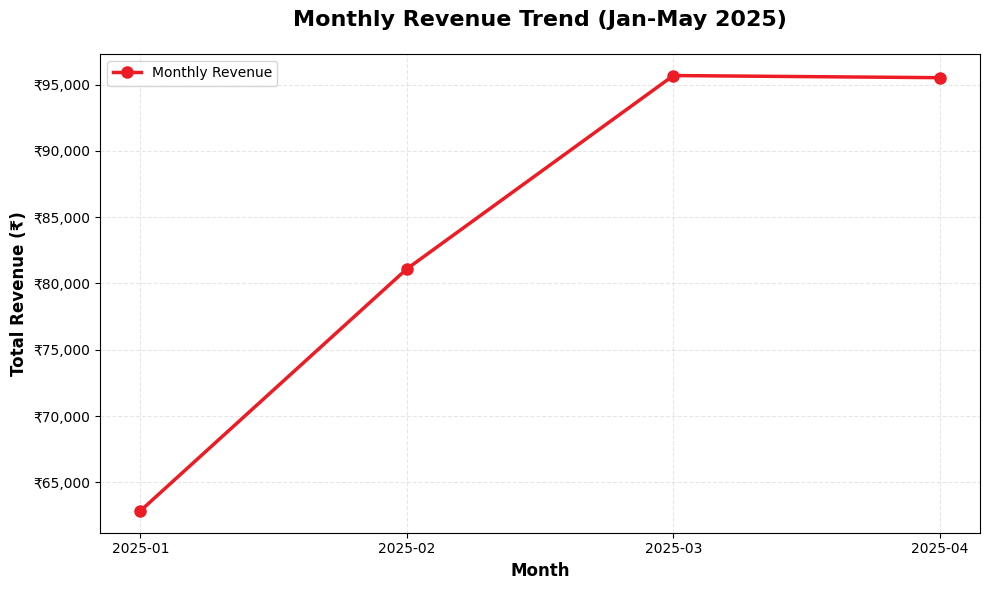

In [19]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Convert Period index to string for plotting
months = monthly_revenue.index.astype(str)
revenue = monthly_revenue.values

# Plot line with markers
ax.plot(months, revenue,
        marker='o',
        markersize=8,
        linewidth=2.5,
        color='#ED1C24',
        label='Monthly Revenue')

# Add title and labels
ax.set_title('Monthly Revenue Trend (Jan-May 2025)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue (₹)', fontsize=12, fontweight='bold')

# Format Y-axis with thousands separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation

The line plot reveals an upward trend in revenue from January through April, with May showing lower values (likely due to partial month data). This type of visualization makes trends immediately obvious — something impossible to see in a 40-row table.

---

## Section 5: Core Plot Type 2 — Bar Plot (Compare Categories)

**Analytical Question:** Which product category generated the highest total revenue?

**When to use Bar Plots:**
- Discrete CATEGORIES (product types, cities, departments)
- You want to COMPARE sizes
- Bar length makes comparison easy

**Data Preparation:** Group by category, sum revenue, and sort.

In [20]:
# Group by product category and sum revenue
category_revenue = ecommerce.groupby('product_category')['total_amount'].sum()

# Sort by revenue (descending)
category_revenue = category_revenue.sort_values(ascending=False)

print("Revenue by Product Category:")
print(category_revenue)
print(f"\nTop Category: {category_revenue.index[0]} (₹{category_revenue.iloc[0]:,})")
print(f"Top category contributes {(category_revenue.iloc[0] / category_revenue.sum() * 100):.1f}% of total revenue")

Revenue by Product Category:
product_category
Electronics       168369
Home & Kitchen     68390
Sports             67888
Books              21293
Clothing            9205
Name: total_amount, dtype: int64

Top Category: Electronics (₹168,369)
Top category contributes 50.2% of total revenue


### Create the Horizontal Bar Plot

We use horizontal bars because category names can be long.

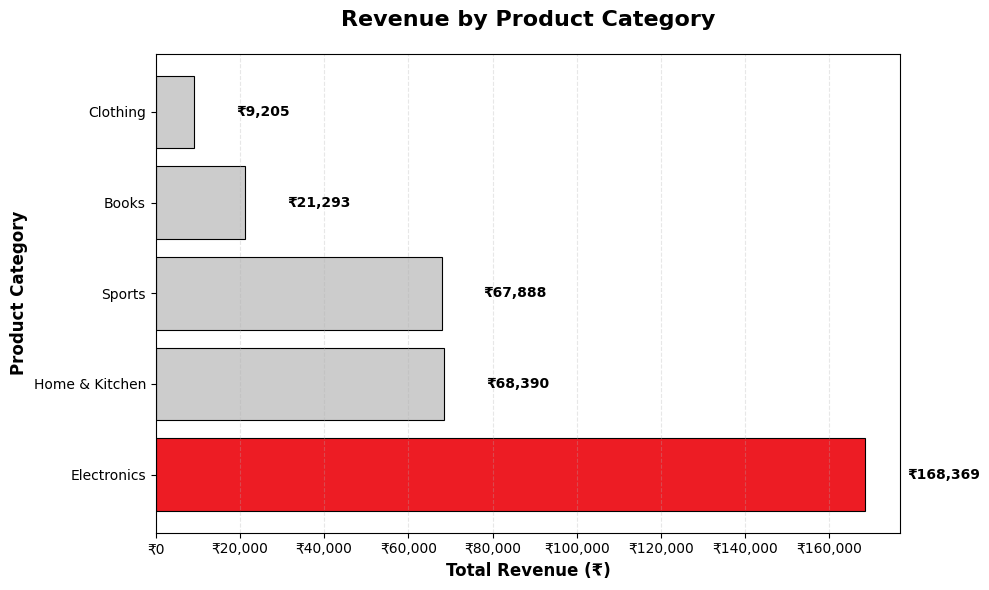

In [21]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Extract categories and revenue
categories = category_revenue.index
revenue = category_revenue.values

# Create color array: top category in  Red, others in gray
colors = ['#ED1C24'] + ['#CCCCCC'] * (len(categories) - 1)

# Create horizontal bar plot
bars = ax.barh(categories, revenue, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels at the end of each bar
for i, (cat, rev) in enumerate(zip(categories, revenue)):
    ax.text(rev + 10000, i, f'₹{rev:,}',
            va='center', fontsize=10, fontweight='bold')

# Add title and labels
ax.set_title('Revenue by Product Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold')

# Format X-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

# Add grid
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The horizontal bar plot makes category comparison effortless. The top category is highlighted in Red, and value labels provide exact revenue figures. This chart instantly reveals which categories drive the business.

---

## Section 6: Core Plot Type 3 — Scatter Plot (Relationships)

**Analytical Question:** Is there a relationship between unit price and customer rating?

**When to use Scatter Plots:**
- TWO CONTINUOUS VARIABLES (price and rating, age and salary)
- Each point is ONE OBSERVATION
- Pattern reveals CORRELATION (or lack thereof)

**Data Preparation:** No aggregation needed — use raw data.

In [22]:
# Extract the two variables
price = ecommerce['unit_price']
rating = ecommerce['customer_rating']

print(f"Plotting {len(price)} orders as individual points")
print(f"Price range: ₹{price.min():,} to ₹{price.max():,}")
print(f"Rating range: {rating.min()} to {rating.max()}")

Plotting 40 orders as individual points
Price range: ₹185 to ₹15,442
Rating range: 2.6 to 5.0


### Create the Scatter Plot

We will color points by product category to see if category affects the pattern.

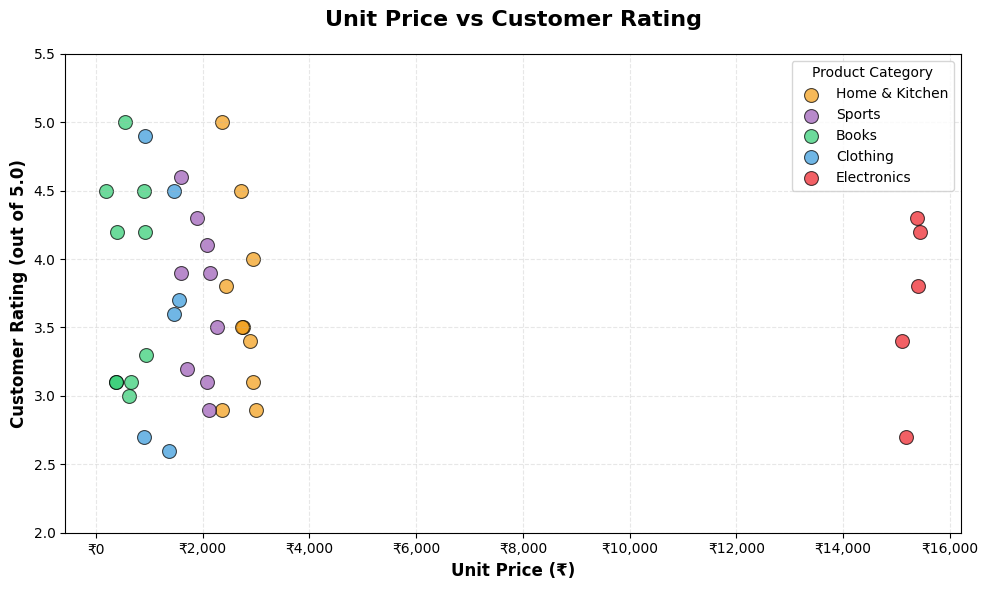

In [23]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Define color mapping for categories
category_colors = {
    'Electronics': '#ED1C24',
    'Clothing': '#3498DB',
    'Books': '#2ECC71',
    'Home & Kitchen': '#F39C12',
    'Sports': '#9B59B6'
}

# Plot each category separately to enable legend
for category in ecommerce['product_category'].unique():
    mask = ecommerce['product_category'] == category
    ax.scatter(ecommerce.loc[mask, 'unit_price'],
               ecommerce.loc[mask, 'customer_rating'],
               label=category,
               color=category_colors[category],
               s=100,
               alpha=0.7,
               edgecolors='black',
               linewidths=0.8)

# Add title and labels
ax.set_title('Unit Price vs Customer Rating', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Unit Price (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Customer Rating (out of 5.0)', fontsize=12, fontweight='bold')

# Format X-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

# Set Y-axis limits
ax.set_ylim(2, 5.5)

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', fontsize=10, title='Product Category')

plt.tight_layout()
plt.show()

### Interpretation

The random scatter of points indicates **no correlation** between price and rating. Expensive products do not automatically receive higher ratings — customers judge products on quality, not price tag. This is a useful negative finding that informs marketing strategy.

---

## Section 7: Core Plot Type 4 — Histogram (Distributions)

**Analytical Question:** What is the distribution of order values? What is the typical order value?

**When to use Histograms:**
- ONE CONTINUOUS VARIABLE (order value, age, temperature)
- You want to understand the SHAPE (distribution)
- Reveals typical values, spread, and outliers

**Data Preparation:** Use total_amount column directly.

In [24]:
# Extract order values
order_values = ecommerce['total_amount']

print(f"Analyzing distribution of {len(order_values)} order values")
print(f"Min: ₹{order_values.min():,}")
print(f"Max: ₹{order_values.max():,}")
print(f"Mean: ₹{order_values.mean():,.0f}")
print(f"Median: ₹{order_values.median():,.0f}")

Analyzing distribution of 40 order values
Min: ₹185
Max: ₹46,326
Mean: ₹8,379
Median: ₹4,158


### Create the Histogram

We will add a vertical line at the mean to show the typical value.

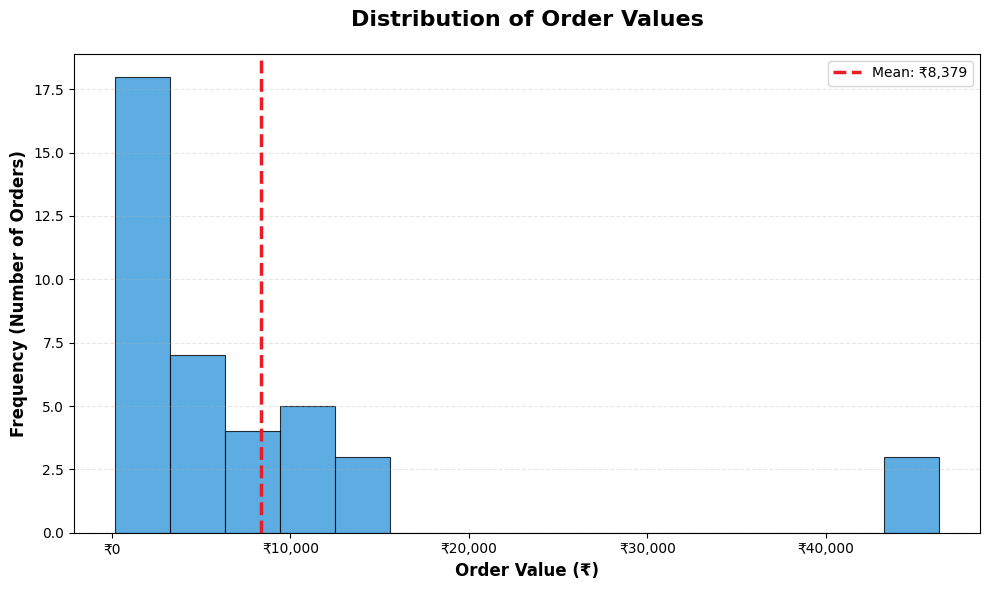

In [25]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with 15 bins
n, bins, patches = ax.hist(order_values,
                            bins=15,
                            color='#3498DB',
                            edgecolor='black',
                            linewidth=0.8,
                            alpha=0.8)

# Add vertical line at the mean
mean_val = order_values.mean()
ax.axvline(mean_val,
           color='#ED1C24',
           linestyle='--',
           linewidth=2.5,
           label=f'Mean: ₹{mean_val:,.0f}')

# Add title and labels
ax.set_title('Distribution of Order Values', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Order Value (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Number of Orders)', fontsize=12, fontweight='bold')

# Format X-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

# Add grid and legend
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [26]:
n

array([18.,  7.,  4.,  5.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  3.])

In [27]:
bins

array([  185.        ,  3261.06666667,  6337.13333333,  9413.2       ,
       12489.26666667, 15565.33333333, 18641.4       , 21717.46666667,
       24793.53333333, 27869.6       , 30945.66666667, 34021.73333333,
       37097.8       , 40173.86666667, 43249.93333333, 46326.        ])

### Interpretation

The histogram reveals a right-skewed distribution — most orders are under ₹30K, with a long right tail from high-value Electronics purchases. The mean is higher than the median due to these outliers, indicating two customer segments: mass market (₹10-30K) and premium (₹50K+).

---

## Section 8: Seaborn Statistical Plots

### What is Seaborn?

Seaborn is a high-level statistical visualization library built on Matplotlib. It provides:
- **DataFrame-native syntax** (pass column names as strings)
- **Beautiful defaults** (publication-quality aesthetics)
- **Statistical focus** (built-in support for distributions, correlations, aggregations)
- **Less code** (2-3 lines vs 15+ in Matplotlib)

Seaborn generates Matplotlib figures under the hood, so all Matplotlib customization still works.

### Set Seaborn Style

In [28]:
# Set default Seaborn style
sns.set_style('whitegrid')
print("Seaborn style set to 'whitegrid'")

Seaborn style set to 'whitegrid'


### Seaborn Plot 1: Countplot (Categorical Frequency)

**Question:** Which cities generate the most orders?

A countplot automatically counts occurrences of each category and displays as bars.

C:\Users\aloks\AppData\Local\Temp\ipykernel_27324\789620940.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ecommerce, x='city', palette='Set2', ax=ax)


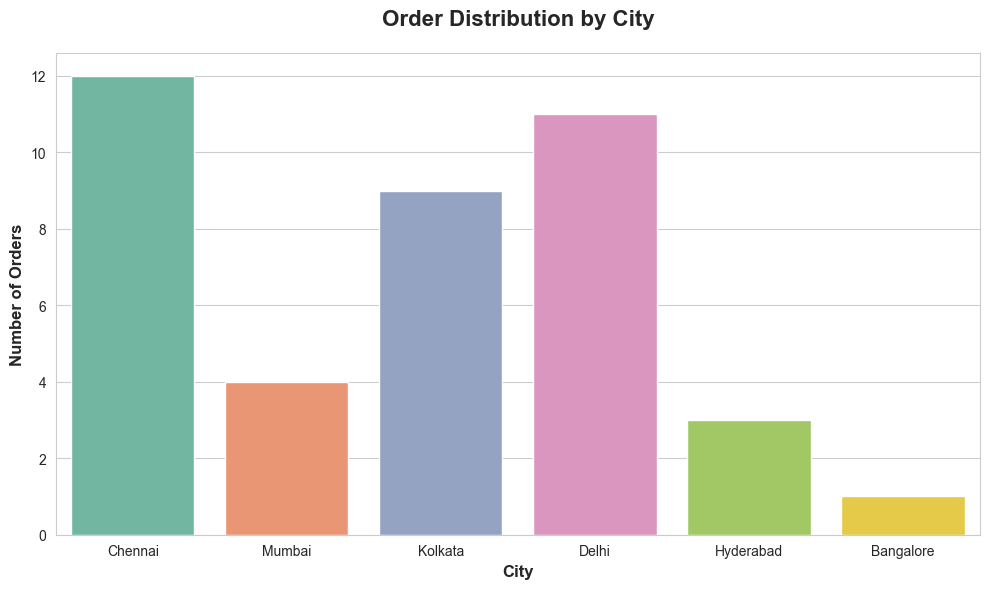

In [29]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create countplot
sns.countplot(data=ecommerce, x='city', palette='Set2', ax=ax)

# Customize
ax.set_title('Order Distribution by City', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('City', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

# Source: Data Storytelling & Interactive Dashboards 2.ipynb



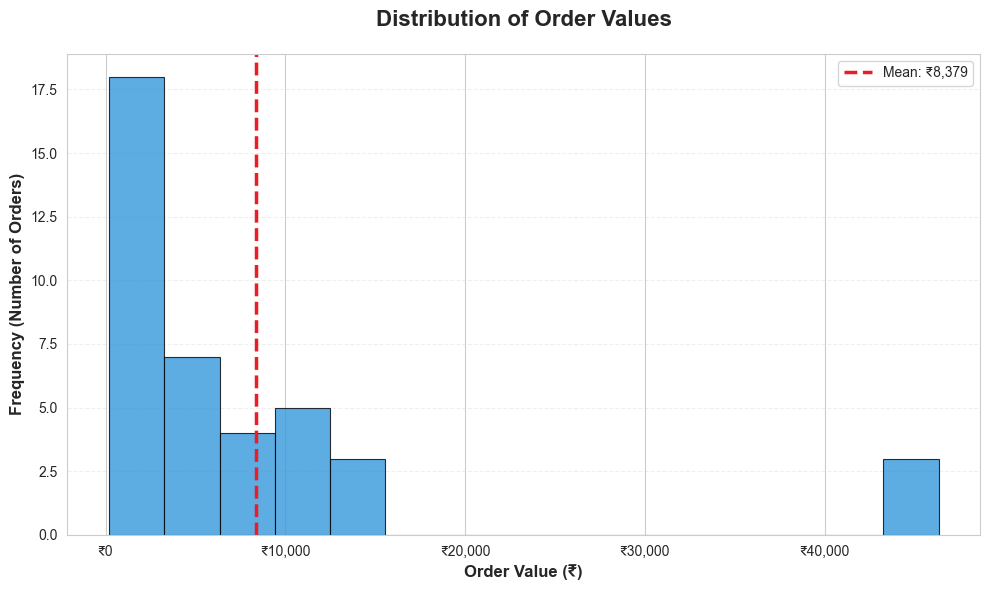

In [30]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with 15 bins
n, bins, patches = ax.hist(order_values,
                            bins=15,
                            color='#3498DB',
                            edgecolor='black',
                            linewidth=0.8,
                            alpha=0.8)

# Add vertical line at the mean
mean_val = order_values.mean()
ax.axvline(mean_val,
           color='#ED1C24',
           linestyle='--',
           linewidth=2.5,
           label=f'Mean: ₹{mean_val:,.0f}')

# Add title and labels
ax.set_title('Distribution of Order Values', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Order Value (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Number of Orders)', fontsize=12, fontweight='bold')
# ax.set_xticks(bins)


# Format X-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

# Add grid and legend
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

### Seaborn Plot 2: Boxplot (Distribution Analysis)

**Question:** How does order value vary across product categories?

A boxplot shows distribution of numeric data across categories, including median, quartiles, and outliers.

C:\Users\aloks\AppData\Local\Temp\ipykernel_27324\2602050732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ecommerce, x='product_category', y='total_amount', palette='Set3', ax=ax)


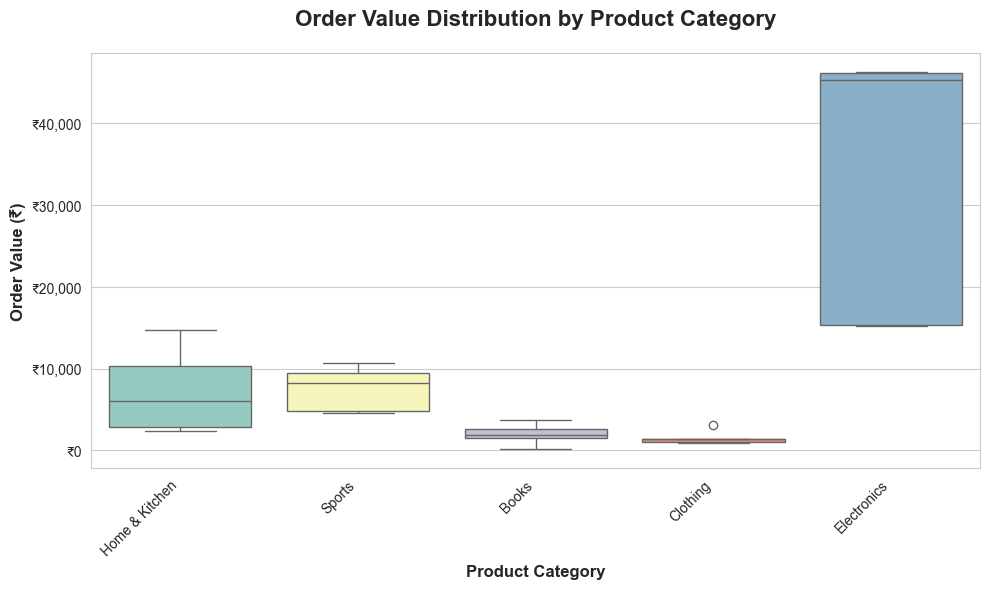

In [31]:
# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot
sns.boxplot(data=ecommerce, x='product_category', y='total_amount', palette='Set3', ax=ax)

# Customize
ax.set_title('Order Value Distribution by Product Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Order Value (₹)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [32]:
ecommerce[ecommerce["product_category"]=="Clothing"]["total_amount"].sort_values()

5      904
13     914
15    1360
39    1456
20    1463
27    3108
Name: total_amount, dtype: int64

### Seaborn Plot 3: Heatmap (Correlation Matrix)

**Question:** What are the correlations between numeric variables?

A heatmap visualizes correlation coefficients as a color grid.

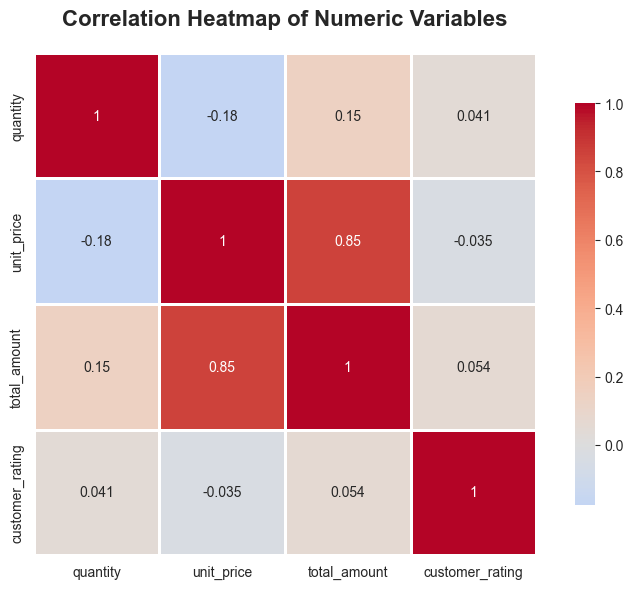

In [33]:
# Select numeric columns
numeric_cols = ['quantity', 'unit_price', 'total_amount', 'customer_rating']

# Compute correlation matrix
corr_matrix = ecommerce[numeric_cols].corr()

# Create Figure and Axes
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)

# Customize
ax.set_title('Correlation Heatmap of Numeric Variables', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### Seaborn Plot 4: Pairplot (Multivariate Exploration)

**Question:** What relationships exist across all numeric variables?

A pairplot creates a grid of scatter plots for every pair of numeric columns, with histograms on the diagonal.

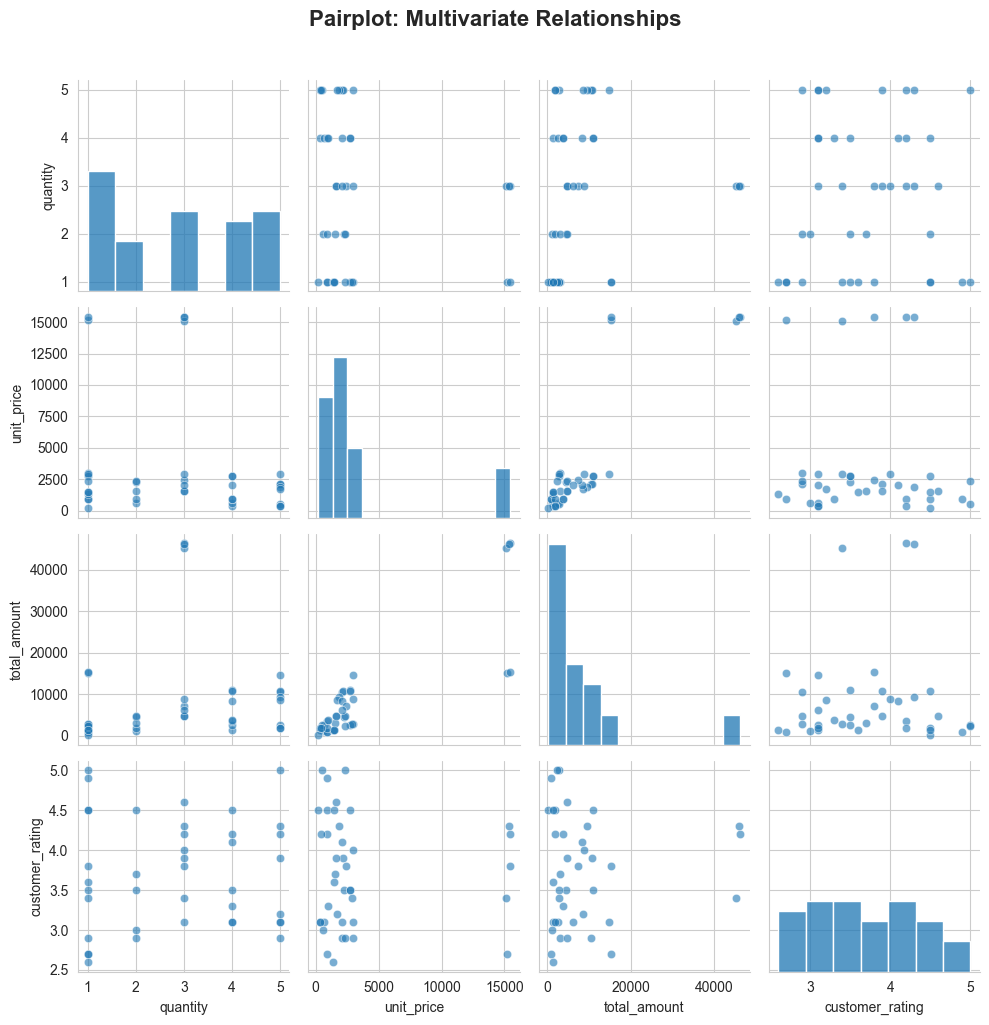

In [34]:
# Create pairplot
pairplot = sns.pairplot(ecommerce[numeric_cols], diag_kind='hist', plot_kws={'alpha': 0.6})
pairplot.fig.suptitle('Pairplot: Multivariate Relationships', y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Section 9: Customization and Styling

### Color Customization

Matplotlib supports colors in multiple formats: named colors, hex codes, RGB tuples, and colormaps.

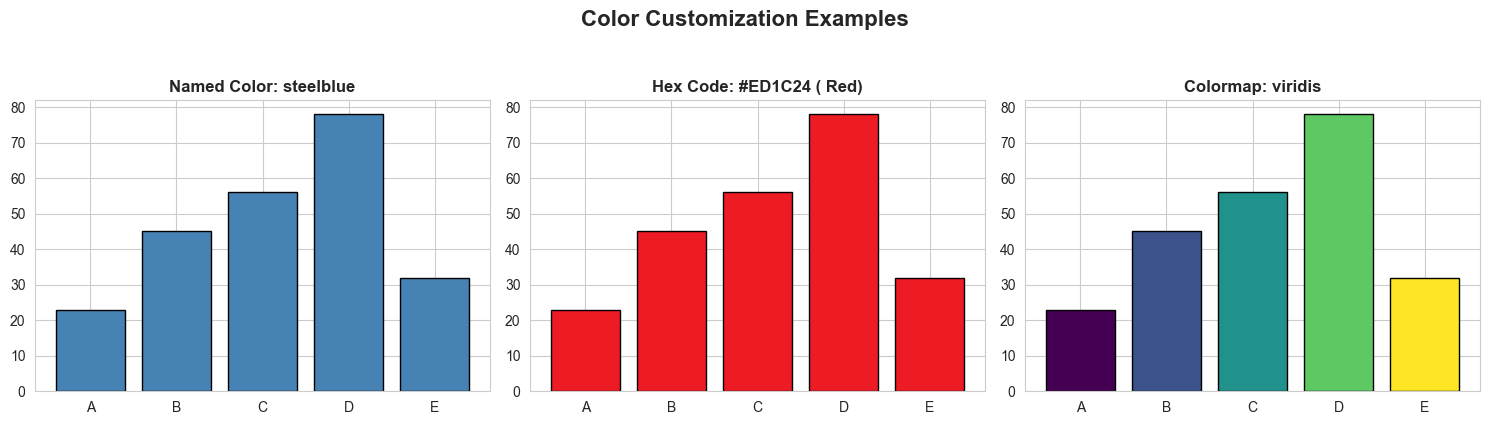

In [35]:
# Create Figure and Axes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample data
categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 78, 32]

# Plot 1: Named colors
axes[0].bar(categories, values, color='steelblue', edgecolor='black')
axes[0].set_title('Named Color: steelblue', fontweight='bold')

# Plot 2: Hex code ( Red)
axes[1].bar(categories, values, color='#ED1C24', edgecolor='black')
axes[1].set_title('Hex Code: #ED1C24 ( Red)', fontweight='bold')

# Plot 3: Colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))
axes[2].bar(categories, values, color=colors, edgecolor='black')
axes[2].set_title('Colormap: viridis', fontweight='bold')

fig.suptitle('Color Customization Examples', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Chart Makeover: From Default to Polished

Let us transform a basic chart into a publication-quality visualization step-by-step.

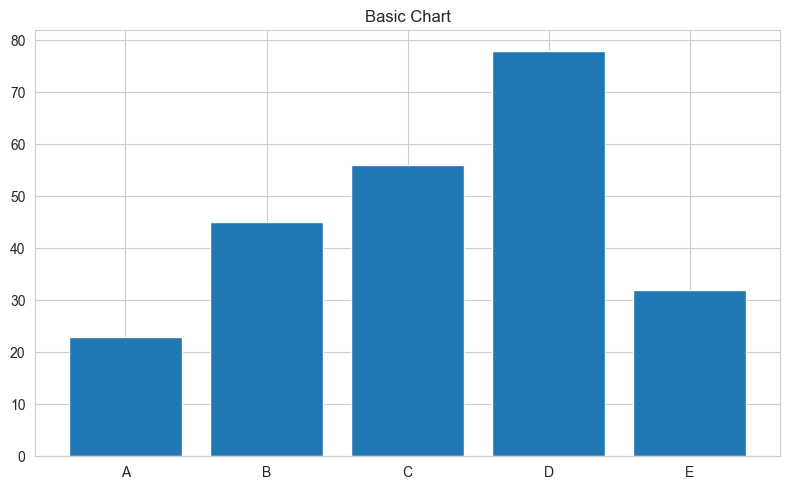

In [36]:
# Step 1: Basic chart (minimal styling)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(categories, values)
ax.set_title('Basic Chart')
plt.tight_layout()
plt.show()

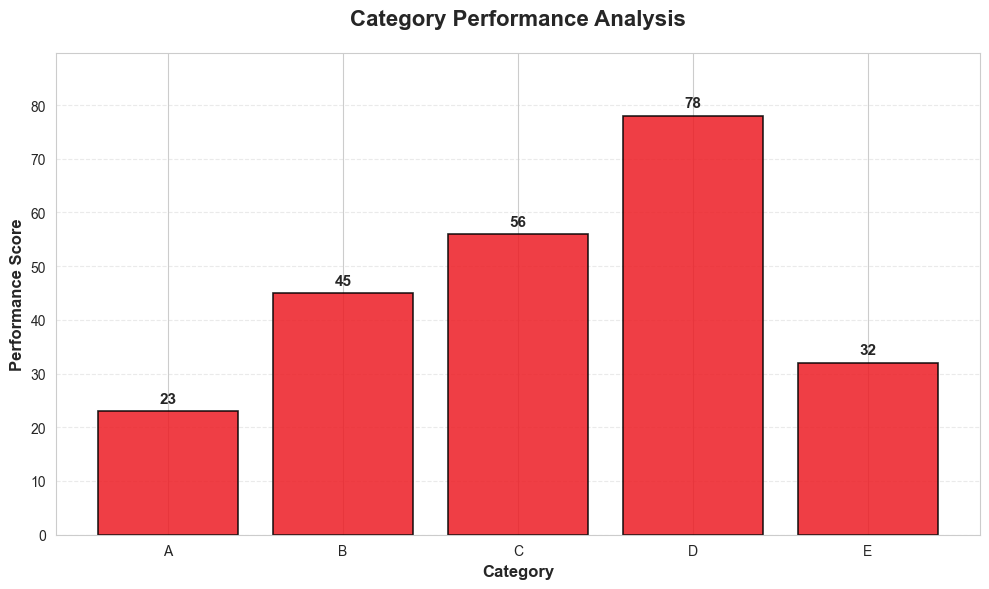

In [37]:
# Step 2: Polished chart (professional styling)
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with custom colors
bars = ax.bar(categories, values, color='#ED1C24', edgecolor='black', linewidth=1.2, alpha=0.85)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add title and labels with custom styling
ax.set_title('Category Performance Analysis', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Performance Score', fontsize=12, fontweight='bold')

# Add grid for easier reading
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Adjust y-axis limits to make room for labels
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()

---

## Section 10: Subplots, Annotations, and Export

### Multi-Panel Figures

Let us create a 2x2 dashboard showing four different chart types on one canvas.

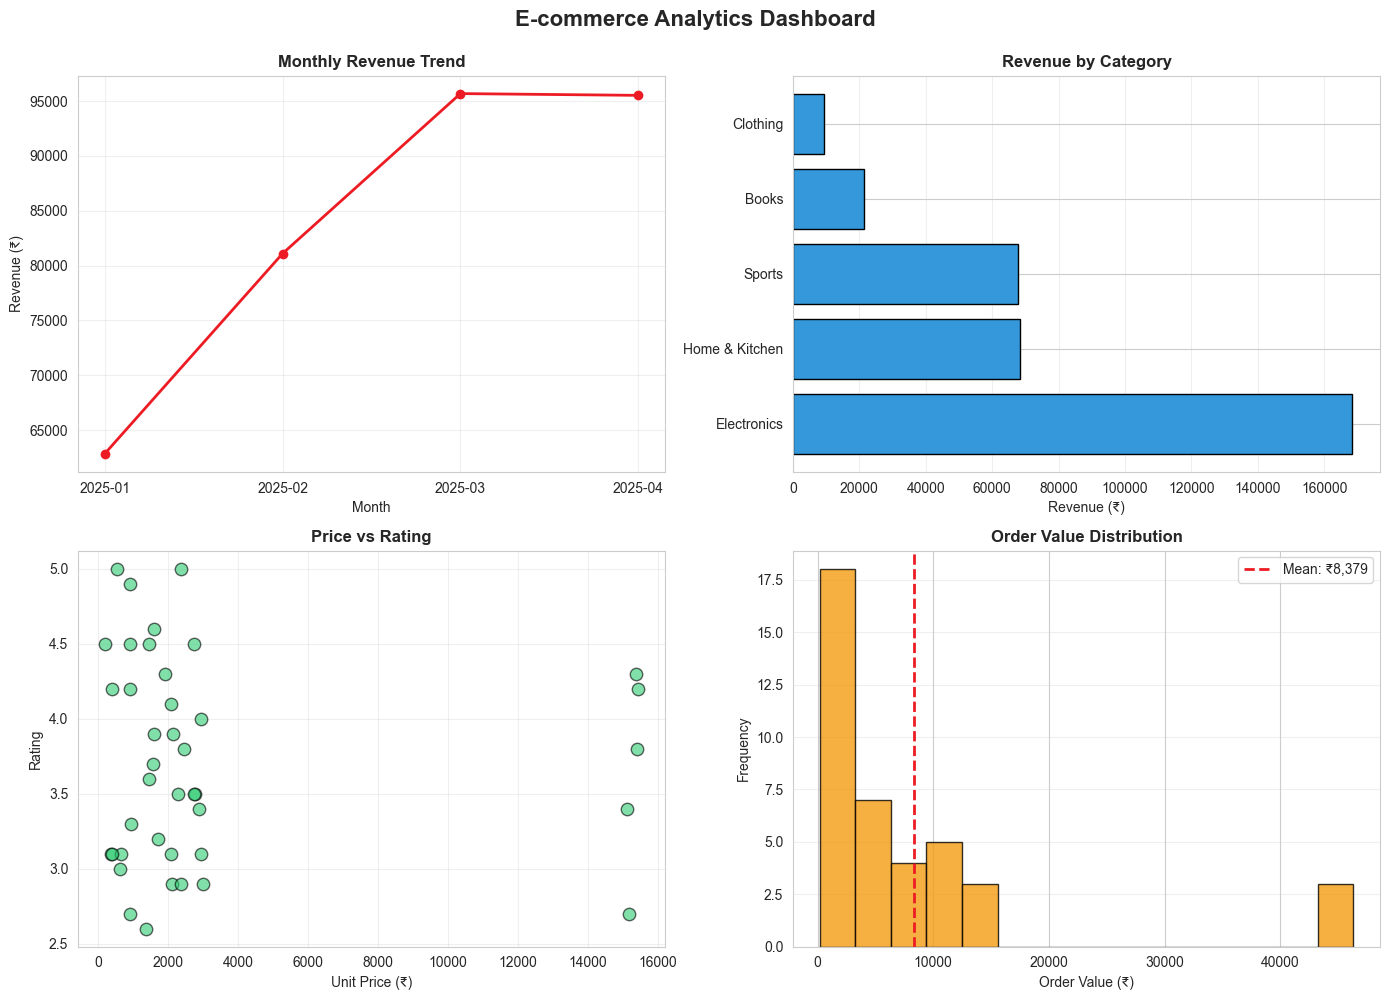

In [38]:
# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Line plot (top-left)
monthly_rev = ecommerce.groupby(ecommerce['order_date'].dt.to_period('M'))['total_amount'].sum()
axes[0, 0].plot(monthly_rev.index.astype(str), monthly_rev.values,
                marker='o', color='#ED1C24', linewidth=2)
axes[0, 0].set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue (₹)')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Bar plot (top-right)
cat_rev = ecommerce.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)
axes[0, 1].barh(cat_rev.index, cat_rev.values, color='#3498DB', edgecolor='black')
axes[0, 1].set_title('Revenue by Category', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Revenue (₹)')
axes[0, 1].grid(True, axis='x', alpha=0.3)

# Panel 3: Scatter plot (bottom-left)
axes[1, 0].scatter(ecommerce['unit_price'], ecommerce['customer_rating'],
                   color='#2ECC71', edgecolors='black', s=80, alpha=0.6)
axes[1, 0].set_title('Price vs Rating', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Unit Price (₹)')
axes[1, 0].set_ylabel('Rating')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Histogram (bottom-right)
axes[1, 1].hist(ecommerce['total_amount'], bins=15, color='#F39C12', edgecolor='black', alpha=0.8)
mean_val = ecommerce['total_amount'].mean()
axes[1, 1].axvline(mean_val, color='#ED1C24', linestyle='--', linewidth=2, label=f'Mean: ₹{mean_val:,.0f}')
axes[1, 1].set_title('Order Value Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Order Value (₹)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y', alpha=0.3)

# Overall title
fig.suptitle('E-commerce Analytics Dashboard', fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

### Adding Annotations

Annotations highlight key data points using arrows and text.

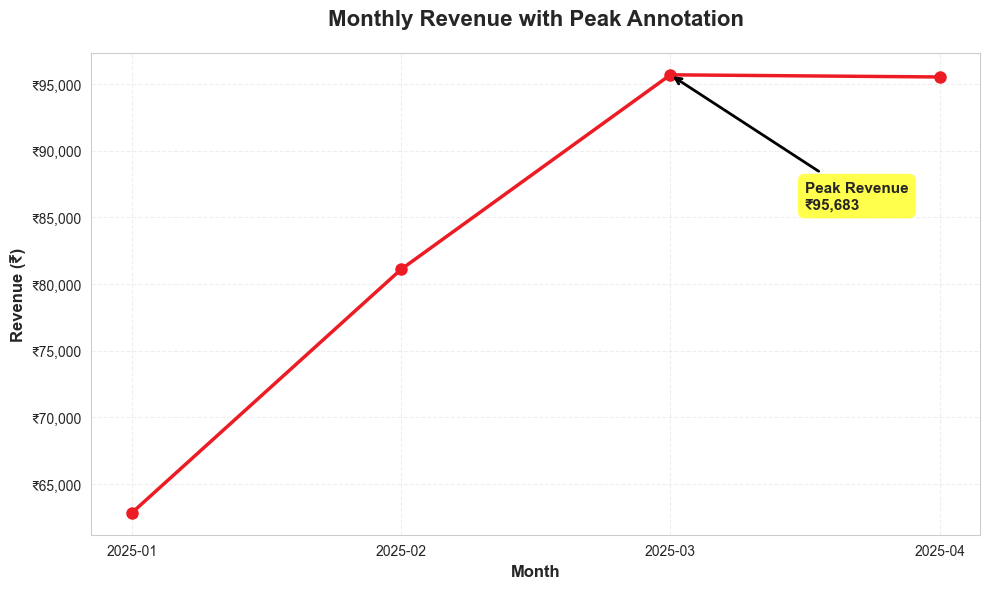

In [39]:
# Create a line plot with annotation
fig, ax = plt.subplots(figsize=(10, 6))

# Monthly revenue data
monthly_rev = ecommerce.groupby(ecommerce['order_date'].dt.to_period('M'))['total_amount'].sum()
months = monthly_rev.index.astype(str)
revenue = monthly_rev.values

# Plot the line
ax.plot(months, revenue, marker='o', color='#ED1C24', linewidth=2.5, markersize=8)

# Find the peak month
peak_idx = np.argmax(revenue)
peak_month = months[peak_idx]
peak_revenue = revenue[peak_idx]

# Add annotation with arrow
ax.annotate(f'Peak Revenue\n₹{peak_revenue:,.0f}',
            xy=(peak_idx, peak_revenue),
            xytext=(peak_idx + 0.5, peak_revenue - 10000),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Customize
ax.set_title('Monthly Revenue with Peak Annotation', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (₹)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Exporting Publication-Quality Figures

Let us create a chart and export it in multiple formats at 300 DPI (publication quality).

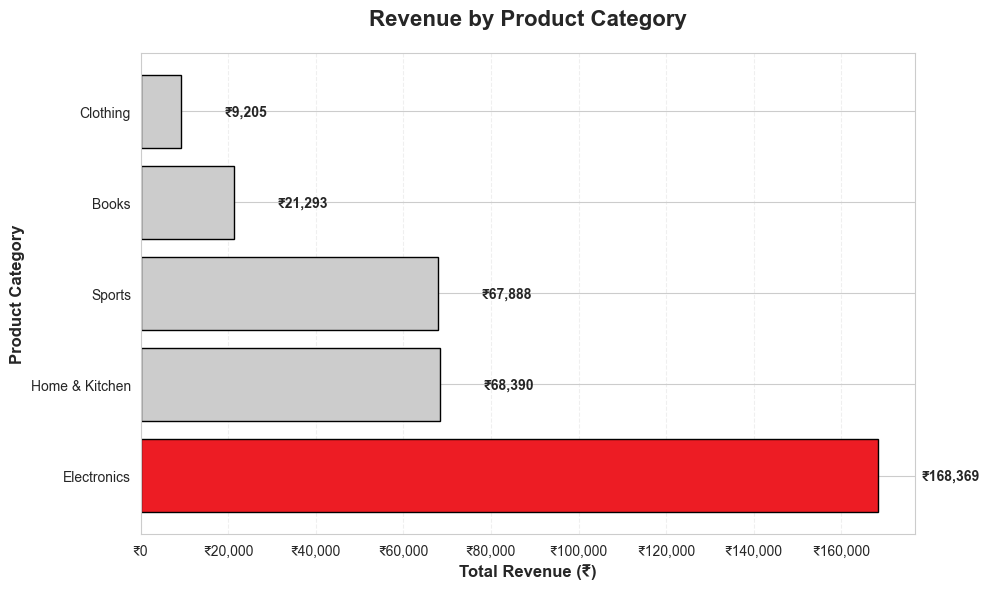

Chart created. Uncomment savefig lines to export.
Recommended export settings:
  - PNG: dpi=300 for publication quality
  - PDF: Vector format, scales without quality loss
  - SVG: Vector format, editable in Illustrator/Inkscape


In [40]:
# Create a professional chart for export
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot of category revenue
cat_rev = ecommerce.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)
colors = ['#ED1C24'] + ['#CCCCCC'] * (len(cat_rev) - 1)
bars = ax.barh(cat_rev.index, cat_rev.values, color=colors, edgecolor='black', linewidth=1)

# Add value labels
for i, (cat, rev) in enumerate(zip(cat_rev.index, cat_rev.values)):
    ax.text(rev + 10000, i, f'₹{rev:,}', va='center', fontsize=10, fontweight='bold')

# Customize
ax.set_title('Revenue by Product Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

# Export in multiple formats
# Uncomment the lines below to save files:
# fig.savefig('category_revenue.png', dpi=300, bbox_inches='tight')
# fig.savefig('category_revenue.pdf', bbox_inches='tight')
# fig.savefig('category_revenue.svg', bbox_inches='tight')

plt.show()

print("Chart created. Uncomment savefig lines to export.")
print("Recommended export settings:")
print("  - PNG: dpi=300 for publication quality")
print("  - PDF: Vector format, scales without quality loss")
print("  - SVG: Vector format, editable in Illustrator/Inkscape")

---

## Section 11: Mini-Project — E-commerce Sales Dashboard

### Challenge Description

Create a comprehensive multi-panel dashboard with 4 charts:

1. **Monthly Revenue Trend** (line plot with annotated peak)
2. **Category Revenue Comparison** (horizontal bar plot with highlighted top category)
3. **Price vs Rating Relationship** (scatter plot colored by category)
4. **Order Value Distribution** (histogram with mean line)

All charts should have consistent styling, proper titles/labels, and be exported at 300 DPI.

### Step 1: Prepare Data for All Panels

In [41]:
# Panel 1 data: Monthly revenue
monthly_revenue = ecommerce.groupby(ecommerce['order_date'].dt.to_period('M'))['total_amount'].sum()

# Panel 2 data: Category revenue
category_revenue = ecommerce.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

# Panel 3 data: Price and rating
price = ecommerce['unit_price']
rating = ecommerce['customer_rating']

# Panel 4 data: Order values
order_values = ecommerce['total_amount']

print("All data prepared for dashboard panels.")

All data prepared for dashboard panels.


### Step 2: Create Panel 1 — Monthly Revenue Trend

In [42]:
# We will create this as part of the complete dashboard in the next step
print("Panel 1 will show monthly revenue trend with peak annotation.")

Panel 1 will show monthly revenue trend with peak annotation.


### Step 3: Create Panel 2 — Category Revenue Comparison

In [43]:
# We will create this as part of the complete dashboard in the next step
print("Panel 2 will show horizontal bar chart with top category highlighted.")

Panel 2 will show horizontal bar chart with top category highlighted.


### Step 4: Create Panel 3 — Price vs Rating Scatter

In [44]:
# We will create this as part of the complete dashboard in the next step
print("Panel 3 will show scatter plot colored by product category.")

Panel 3 will show scatter plot colored by product category.


### Step 5: Create Panel 4 — Order Value Distribution

In [45]:
# We will create this as part of the complete dashboard in the next step
print("Panel 4 will show histogram with mean line.")

Panel 4 will show histogram with mean line.


### Complete Dashboard: All 4 Panels Combined

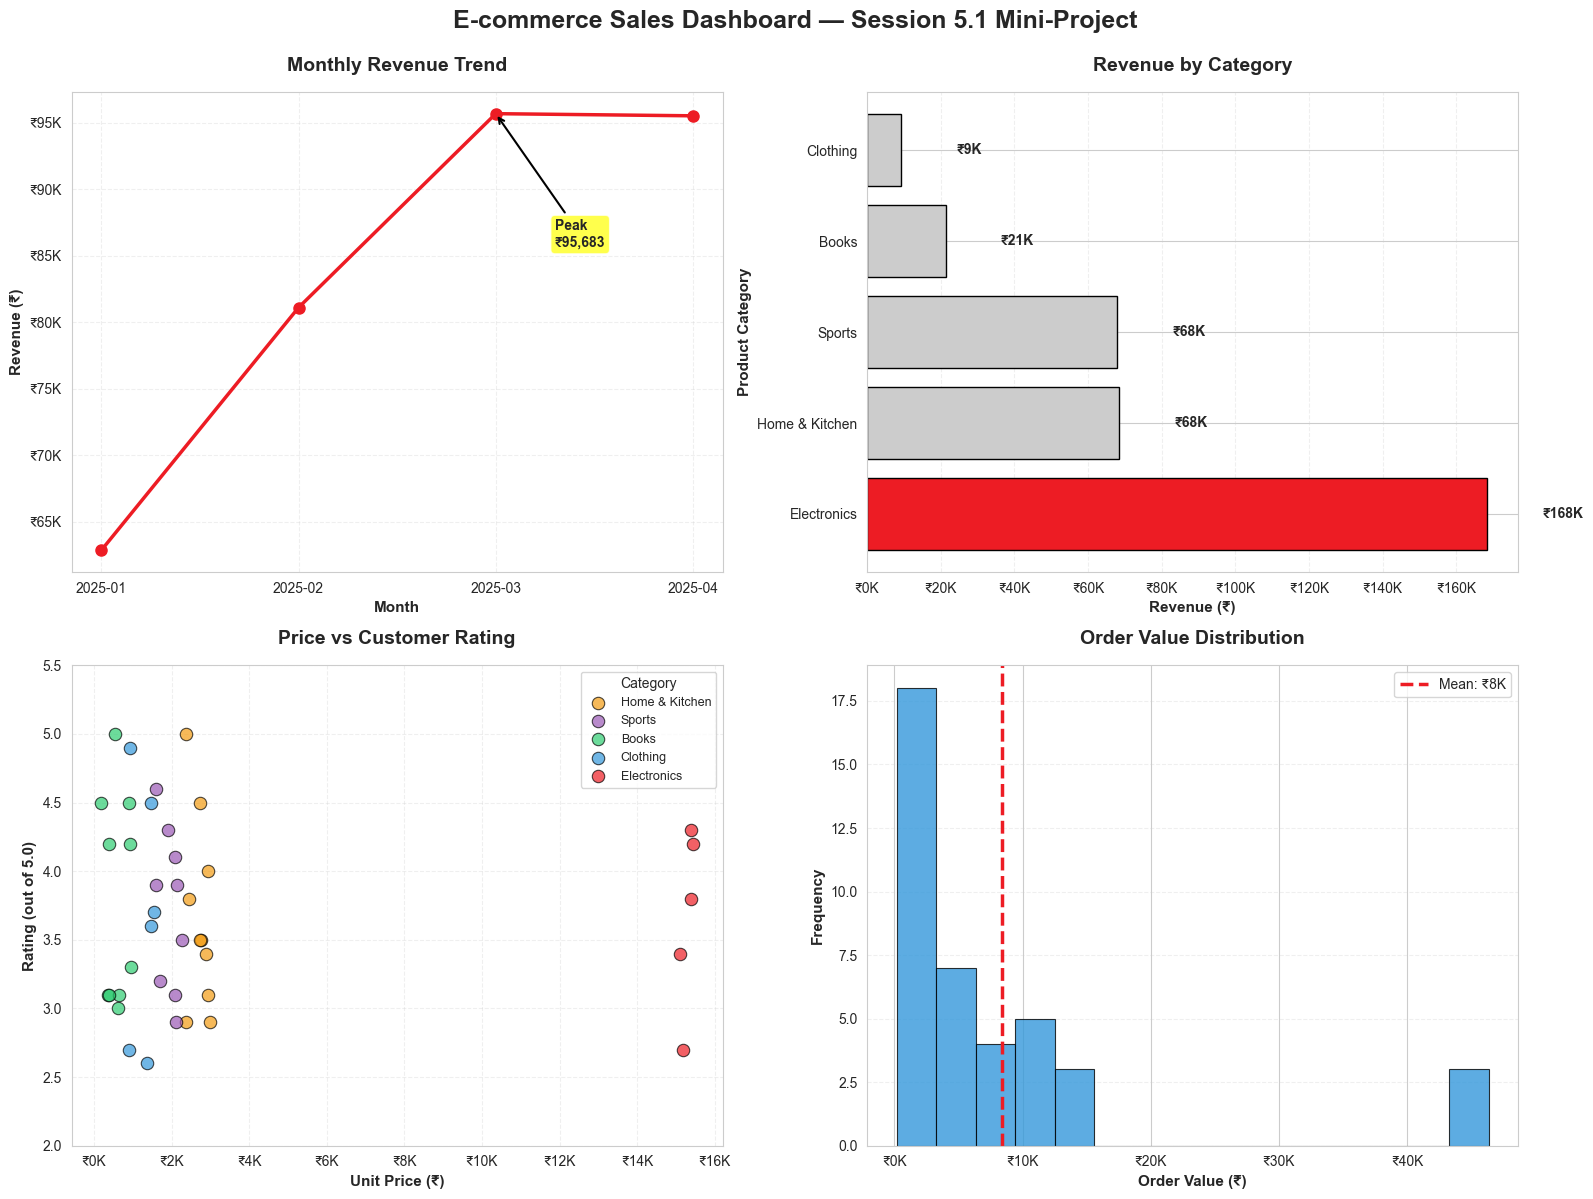


=== DASHBOARD COMPLETE ===
All 4 panels created with consistent styling.
Uncomment the savefig line to export at 300 DPI.


In [46]:
# Create 2x2 subplot grid for the dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ====================
# PANEL 1: Monthly Revenue Trend
# ====================
months_str = monthly_revenue.index.astype(str)
revenue_vals = monthly_revenue.values

axes[0, 0].plot(months_str, revenue_vals, marker='o', markersize=8,
                linewidth=2.5, color='#ED1C24')

# Annotate peak
peak_idx = np.argmax(revenue_vals)
axes[0, 0].annotate(f'Peak\n₹{revenue_vals[peak_idx]:,.0f}',
                    xy=(peak_idx, revenue_vals[peak_idx]),
                    xytext=(peak_idx + 0.3, revenue_vals[peak_idx] - 10000),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

axes[0, 0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Month', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Revenue (₹)', fontsize=11, fontweight='bold')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# ====================
# PANEL 2: Category Revenue
# ====================
cat_names = category_revenue.index
cat_vals = category_revenue.values
colors_cat = ['#ED1C24'] + ['#CCCCCC'] * (len(cat_names) - 1)

axes[0, 1].barh(cat_names, cat_vals, color=colors_cat, edgecolor='black', linewidth=1)

# Add value labels
for i, (cat, val) in enumerate(zip(cat_names, cat_vals)):
    axes[0, 1].text(val + 15000, i, f'₹{val/1000:.0f}K',
                    va='center', fontsize=10, fontweight='bold')

axes[0, 1].set_title('Revenue by Category', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Revenue (₹)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Product Category', fontsize=11, fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
axes[0, 1].grid(True, axis='x', linestyle='--', alpha=0.3)

# ====================
# PANEL 3: Price vs Rating Scatter
# ====================
category_colors = {
    'Electronics': '#ED1C24',
    'Clothing': '#3498DB',
    'Books': '#2ECC71',
    'Home & Kitchen': '#F39C12',
    'Sports': '#9B59B6'
}

for category in ecommerce['product_category'].unique():
    mask = ecommerce['product_category'] == category
    axes[1, 0].scatter(ecommerce.loc[mask, 'unit_price'],
                       ecommerce.loc[mask, 'customer_rating'],
                       label=category,
                       color=category_colors[category],
                       s=80, alpha=0.7,
                       edgecolors='black', linewidths=0.8)

axes[1, 0].set_title('Price vs Customer Rating', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Unit Price (₹)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Rating (out of 5.0)', fontsize=11, fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
axes[1, 0].set_ylim(2, 5.5)
axes[1, 0].grid(True, linestyle='--', alpha=0.3)
axes[1, 0].legend(loc='upper right', fontsize=9, title='Category')

# ====================
# PANEL 4: Order Value Distribution
# ====================
axes[1, 1].hist(order_values, bins=15, color='#3498DB',
                edgecolor='black', linewidth=0.8, alpha=0.8)

# Add mean line
mean_val = order_values.mean()
axes[1, 1].axvline(mean_val, color='#ED1C24', linestyle='--',
                   linewidth=2.5, label=f'Mean: ₹{mean_val/1000:.0f}K')

axes[1, 1].set_title('Order Value Distribution', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('Order Value (₹)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))
axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.3)
axes[1, 1].legend(loc='upper right', fontsize=10)

# ====================
# OVERALL STYLING
# ====================
fig.suptitle('E-commerce Sales Dashboard — Session 5.1 Mini-Project',
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()

# Export at 300 DPI
# Uncomment to save:
# fig.savefig('ecommerce_dashboard.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n=== DASHBOARD COMPLETE ===")
print("All 4 panels created with consistent styling.")
print("Uncomment the savefig line to export at 300 DPI.")

## Business Story: The Hans Rosling Moment

In February 2006, Hans Rosling — a Swedish professor of global health — walked onto the TED stage and gave a presentation that changed how the world understands global development. His talk, "The Best Stats You've Ever Seen," has been viewed over 14 million times.

Rosling used an **animated bubble chart** to present 200 years of health and wealth data for 200 countries. The audience — United Nations diplomats, policy makers, and global leaders — watched, stunned, as their deeply held assumptions about "developing" versus "developed" countries were demolished in real time.

**The insight was not new** — the data had been publicly available for years. Nobody looked at it because nobody presented it compellingly.

Rosling's breakthrough was in **PRESENTATION**: an animated, interactive visualization that transformed a static spreadsheet into a narrative that shattered myths and drove policy.

**Today's lesson:** Data without a story is noise. A story without data is opinion. Interactive data storytelling combines both into influence.

## Setup

Run the cell below to import the required libraries. You need **Pandas**, **NumPy**, **Plotly Express**, **Matplotlib**, and **Seaborn** installed.

In [47]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")
print(f"Plotly version: {px.__version__ if hasattr(px, '__version__') else 'unknown'}")
print()
print("Ready to make charts tell stories!")

Pandas version: 3.0.2
NumPy version:  2.4.4
Plotly version: unknown

Ready to make charts tell stories!


<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 1: Data Storytelling Principles</h2>
    <p style="margin:5px 0 0 0; font-size:14px;">From Data Dump to Data Story</p>
</div>

<div style="background: #EBF5FB; color:gray; border-left: 5px solid #3498DB; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Key Concept — Three Levels of Data Communication:</strong><br><br>
    <strong>Level 1: Data Dump</strong> — Raw tables nobody reads. The reader must do all the interpretive work.<br>
    <strong>Level 2: Chart Collection</strong> — Pretty charts with no narrative thread. No interpretation, no recommendation.<br>
    <strong>Level 3: Data Story</strong> — Data + Narrative + Visuals, structured to guide the audience from context through insight to action.<br><br>
    <strong>Most analysts stop at Level 2. The ones who get promoted reach Level 3.</strong>
</div>

### Create the Gapminder-Style Dataset

This dataset contains 12 countries across 5 time periods (2000-2020) with life expectancy, GDP per capita, population, and continent information. We will use this throughout the session to demonstrate data storytelling principles and create the famous Rosling animated bubble chart.

In [48]:
# ============================================================
# SESSION DATASET: Gapminder-Style Global Development Data
# 12 countries × 5 years = 60 rows
# Used in Part 1 (storytelling) and Part 3 (animated bubble chart)
# ============================================================

gapminder = pd.DataFrame({
    'country': ['India']*5 + ['China']*5 + ['Japan']*5 + ['Germany']*5 +
               ['UK']*5 + ['Nigeria']*5 + ['South Africa']*5 + ['Brazil']*5 +
               ['USA']*5 + ['Australia']*5 + ['Bangladesh']*5 + ['Ethiopia']*5,
    'continent': ['Asia']*5 + ['Asia']*5 + ['Asia']*5 + ['Europe']*5 +
                 ['Europe']*5 + ['Africa']*5 + ['Africa']*5 + ['Americas']*5 +
                 ['Americas']*5 + ['Oceania']*5 + ['Asia']*5 + ['Africa']*5,
    'year': [2000, 2005, 2010, 2015, 2020] * 12,
    'life_expectancy': [
        62.5, 64.0, 66.5, 68.3, 70.1,    # India
        71.4, 73.0, 75.0, 76.1, 77.1,    # China
        81.1, 82.0, 83.0, 83.8, 84.6,    # Japan
        78.1, 79.4, 80.4, 80.8, 81.3,    # Germany
        77.8, 79.0, 80.4, 81.0, 81.3,    # UK
        46.6, 48.4, 51.3, 54.0, 55.8,    # Nigeria
        55.0, 52.1, 56.0, 62.4, 64.1,    # South Africa
        70.3, 71.7, 73.1, 75.2, 75.9,    # Brazil
        76.6, 77.6, 78.5, 78.7, 78.9,    # USA
        79.4, 80.9, 82.0, 82.5, 83.4,    # Australia
        65.3, 67.0, 69.4, 71.8, 73.0,    # Bangladesh
        52.1, 55.0, 60.0, 64.0, 66.6     # Ethiopia
    ],
    'gdp_per_capita': [
        1900, 2800, 4500, 6200, 6500,    # India
        3700, 5500, 9100, 13400, 16800,  # China
        37200, 39400, 43000, 38100, 40200, # Japan
        29000, 34100, 40100, 47800, 46200, # Germany
        28200, 37600, 38900, 43300, 41100, # UK
        1500, 2100, 3400, 5400, 4900,    # Nigeria
        7700, 8600, 10700, 12500, 11500, # South Africa
        8500, 9700, 12800, 14700, 13900, # Brazil
        45000, 48200, 49400, 56200, 63500, # USA
        33500, 39100, 42200, 49900, 51700, # Australia
        1200, 1500, 2500, 3500, 5100,    # Bangladesh
        800, 1100, 1400, 1800, 2400      # Ethiopia
    ],
    'population': [
        1053, 1131, 1210, 1310, 1380,    # India (millions)
        1267, 1304, 1341, 1376, 1412,    # China
        127, 128, 128, 127, 126,         # Japan
        82, 82, 82, 82, 83,             # Germany
        59, 60, 63, 65, 67,             # UK
        123, 139, 159, 182, 206,        # Nigeria
        44, 47, 50, 55, 59,            # South Africa
        175, 186, 196, 206, 213,        # Brazil
        282, 296, 310, 321, 331,        # USA
        19, 20, 22, 24, 26,            # Australia
        131, 143, 148, 157, 165,        # Bangladesh
        66, 74, 88, 100, 115            # Ethiopia
    ]
})

print(f"Dataset loaded: {gapminder.shape[0]} rows × {gapminder.shape[1]} columns")
print(f"Countries: {gapminder['country'].nunique()}")
print(f"Years: {sorted(gapminder['year'].unique())}")

Dataset loaded: 60 rows × 6 columns
Countries: 12
Years: [np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020)]


### Level 1: Data Dump — Nobody Reads This

In [49]:
# LEVEL 1: Show the raw data — overwhelming and uninformative
print("=" * 60)
print("LEVEL 1: DATA DUMP — Raw Table")
print("=" * 60)
gapminder.head(20)

LEVEL 1: DATA DUMP — Raw Table


,country,continent,year,life_expectancy,gdp_per_capita,population
0,India,Asia,2000,62.5,1900,1053
1,India,Asia,2005,64.0,2800,1131
2,India,Asia,2010,66.5,4500,1210
3,India,Asia,2015,68.3,6200,1310
4,India,Asia,2020,70.1,6500,1380
5,China,Asia,2000,71.4,3700,1267
6,China,Asia,2005,73.0,5500,1304
7,China,Asia,2010,75.0,9100,1341
8,China,Asia,2015,76.1,13400,1376
9,China,Asia,2020,77.1,16800,1412


<div style="background: #FEF9E7; color: gray; border-left: 5px solid #F39C12; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Question:</strong> Looking at these 20 rows — can you tell which continent improved the most in life expectancy? Which countries are pulling the average up or down? Is the gap closing or widening?<br><br>
    <strong>Answer:</strong> You cannot. The information IS in there — but your brain cannot extract it from a wall of numbers.<br><br>
    <strong>This is why nobody reads spreadsheets. This is why executives ignore your email attachment.</strong>
</div>

### Level 2: Summary Statistics — Better, But Not Enough

In [50]:
# LEVEL 2: Summary statistics — better than raw data, but still insufficient
print("=" * 60)
print("LEVEL 2: SUMMARY STATISTICS — Better, But Not Enough")
print("=" * 60)

continent_summary = gapminder.groupby('continent')['life_expectancy'].agg(
    ['mean', 'min', 'max']
).round(1)

print("\nLife Expectancy by Continent (across all years):")
continent_summary

LEVEL 2: SUMMARY STATISTICS — Better, But Not Enough

Life Expectancy by Continent (across all years):


,mean,min,max
continent,,,
Africa,56.2,46.6,66.6
Americas,75.6,70.3,78.9
Asia,73.2,62.5,84.6
Europe,80.0,77.8,81.3
Oceania,81.6,79.4,83.4


In [51]:
# GDP per capita summary
gdp_summary = gapminder.groupby('continent')['gdp_per_capita'].agg(
    ['mean', 'min', 'max']
).round(0)

print("GDP per Capita by Continent (across all years):")
gdp_summary

GDP per Capita by Continent (across all years):


,mean,min,max
continent,,,
Africa,5053.0,800,12500
Americas,32190.0,8500,63500
Asia,14105.0,1200,43000
Europe,38630.0,28200,47800
Oceania,43280.0,33500,51700


<div style="background: #EBF5FB; color: gray; border-left: 5px solid #3498DB; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>What's Missing:</strong> We can see Africa has lower life expectancy and GDP. But WHICH year? Which countries are pulling the average up or down? Is the gap closing or widening? Are some African countries improving faster than others?<br><br>
    <strong>The summary statistics cannot answer any of these questions. You lose the time dimension. You lose the country-level variation. You lose the STORY.</strong>
</div>

### Level 3: Data Story — The Context-to-Insight-to-Action Framework

Every effective data presentation follows this structure:

1. **CONTEXT:** Why are we looking at this? What situation prompted the analysis?
2. **INSIGHT:** What did the data reveal? The specific finding, pattern, or anomaly.
3. **ACTION:** What should the audience DO differently? The clear recommendation.

**In Part 3, we will visualize this dataset with an animated bubble chart — the Rosling moment — that tells the story in 20 seconds.**

<div style="background: #EAFAF1; color: gray; border-left: 5px solid #2ECC71; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Best Practice — Dashboard Narrative Flow:</strong><br><br>
    Professional dashboards follow an <strong>inverted pyramid</strong> structure:<br><br>
    1. <strong>SUMMARY (Top):</strong> KPI metric cards — the 3-5 most important numbers<br>
    2. <strong>TREND (Middle-Top):</strong> Line charts showing how KPIs change over time<br>
    3. <strong>BREAKDOWN (Middle-Bottom):</strong> Bar charts comparing categories/segments<br>
    4. <strong>DETAIL (Bottom):</strong> Filtered tables, scatter plots, granular exploration<br><br>
    <strong>A VP gets the answer in 5 seconds. An analyst can spend 15 minutes exploring. Same dashboard serves both audiences.</strong>
</div>

<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 2: Chart Selection & Redesign</h2>
    <p style="margin:5px 0 0 0; font-size:14px;">Choosing the Right Chart and Fixing Chart Crimes</p>
</div>

<div style="background: #F5F5F5; color: gray; border-left: 5px solid #999; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Chart Selection Decision Tree:</strong><br><br>
    <strong>Analytical Question</strong> → <strong>Chart Type</strong><br><br>
    • "How does X change over time?" → <strong>Line Chart</strong><br>
    • "How do categories compare?" → <strong>Bar Chart</strong> (horizontal if 5+ categories)<br>
    • "What is the relationship between X and Y?" → <strong>Scatter Plot</strong><br>
    • "What is the distribution of values?" → <strong>Histogram</strong><br>
    • "What is the composition/proportion?" → <strong>Stacked Bar / Pie Chart</strong> (use pie sparingly)<br>
</div>

### Three Common Chart Crimes

1. **Truncated Y-Axis:** Starting the y-axis at a value other than zero to exaggerate small changes
2. **Chart Junk:** Decorative backgrounds, 3D effects, unnecessary gridlines that obscure the data
3. **Wrong Chart Type:** Using a pie chart for 10+ categories, or a line chart for non-sequential data

### Live Chart Redesign: BEFORE vs AFTER

In [52]:
# Sample revenue data by category
categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports']
revenue = [245000, 189000, 67000, 134000, 98000]

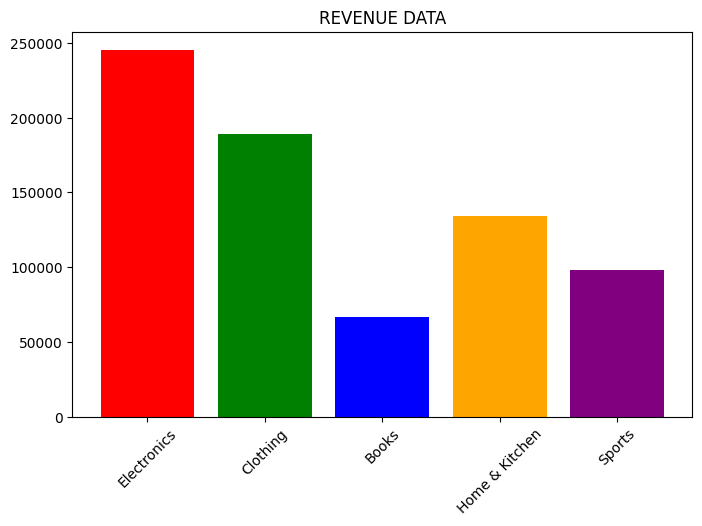

Chart crimes committed:
1. Generic title 'REVENUE DATA' — no insight
2. Five garish rainbow colors — meaningless
3. Red and green side by side — colorblind inaccessible
4. Vertical bars with rotated labels — hard to read
5. Not sorted by value
6. No axis labels — revenue in what units?
7. No value labels — must trace to y-axis


In [53]:
# ── BEFORE: The "Chart Crime" Version ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(categories, revenue, color=['red', 'green', 'blue', 'orange', 'purple'])
ax.set_title('REVENUE DATA')
plt.xticks(rotation=45)
plt.show()

print("Chart crimes committed:")
print("1. Generic title 'REVENUE DATA' — no insight")
print("2. Five garish rainbow colors — meaningless")
print("3. Red and green side by side — colorblind inaccessible")
print("4. Vertical bars with rotated labels — hard to read")
print("5. Not sorted by value")
print("6. No axis labels — revenue in what units?")
print("7. No value labels — must trace to y-axis")

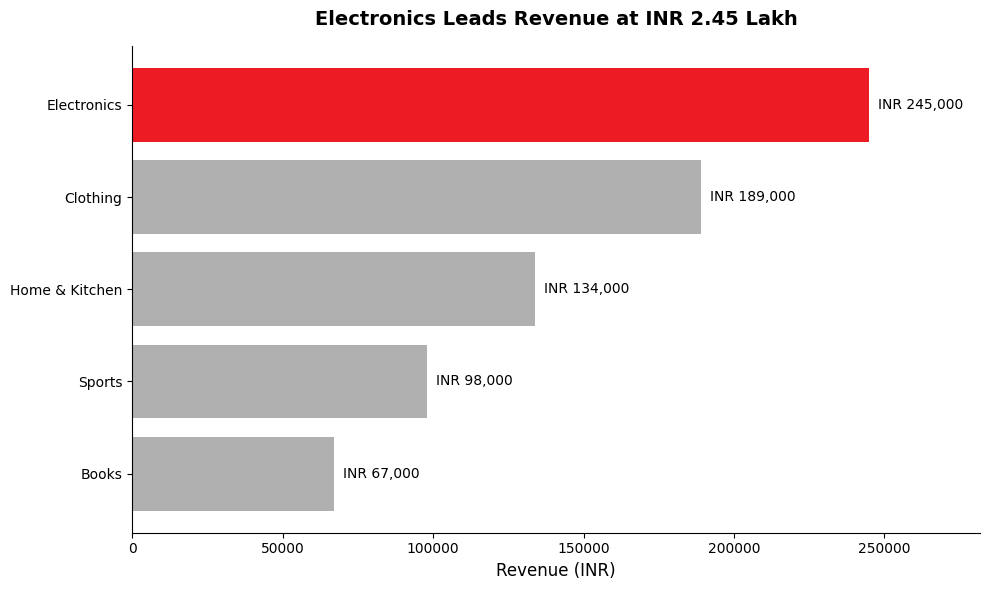

Every change made:
1. Horizontal orientation → labels read naturally
2. Sorted by value → largest at top
3. Single gray + one red accent → eye goes to the insight
4. Removed top/right spines → less clutter
5. Value labels on each bar → no tracing to axis
6. Insight headline → tells the story


In [54]:
# ── AFTER: The Professional Redesign ──
fig, ax = plt.subplots(figsize=(10, 6))

# Step 1: Sort by revenue (ascending for horizontal bar chart)
sorted_indices = np.argsort(revenue)
sorted_categories = [categories[i] for i in sorted_indices]
sorted_revenue = [revenue[i] for i in sorted_indices]

# Step 2: Use a single professional color with accent on top bar
colors = ['#B0B0B0'] * len(sorted_revenue)
colors[-1] = '#ED1C24'  # Masai Red for the top category

# Step 3: Horizontal bar chart — labels are readable
ax.barh(sorted_categories, sorted_revenue, color=colors, edgecolor='none')

# Step 4: Insight headline as title
ax.set_xlabel('Revenue (INR)', fontsize=12)
ax.set_title('Electronics Leads Revenue at INR 2.45 Lakh',
             fontsize=14, fontweight='bold', pad=15)

# Step 5: Remove unnecessary spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Step 6: Add value labels
for i, (val, cat) in enumerate(zip(sorted_revenue, sorted_categories)):
    ax.text(val + 3000, i, f'INR {val:,}', va='center', fontsize=10)

# Step 7: Give the value labels room
ax.set_xlim(0, max(sorted_revenue) * 1.15)

fig.tight_layout()
plt.show()

print("Every change made:")
print("1. Horizontal orientation → labels read naturally")
print("2. Sorted by value → largest at top")
print("3. Single gray + one red accent → eye goes to the insight")
print("4. Removed top/right spines → less clutter")
print("5. Value labels on each bar → no tracing to axis")
print("6. Insight headline → tells the story")

### Color Theory: Colorblind-Friendly Palettes

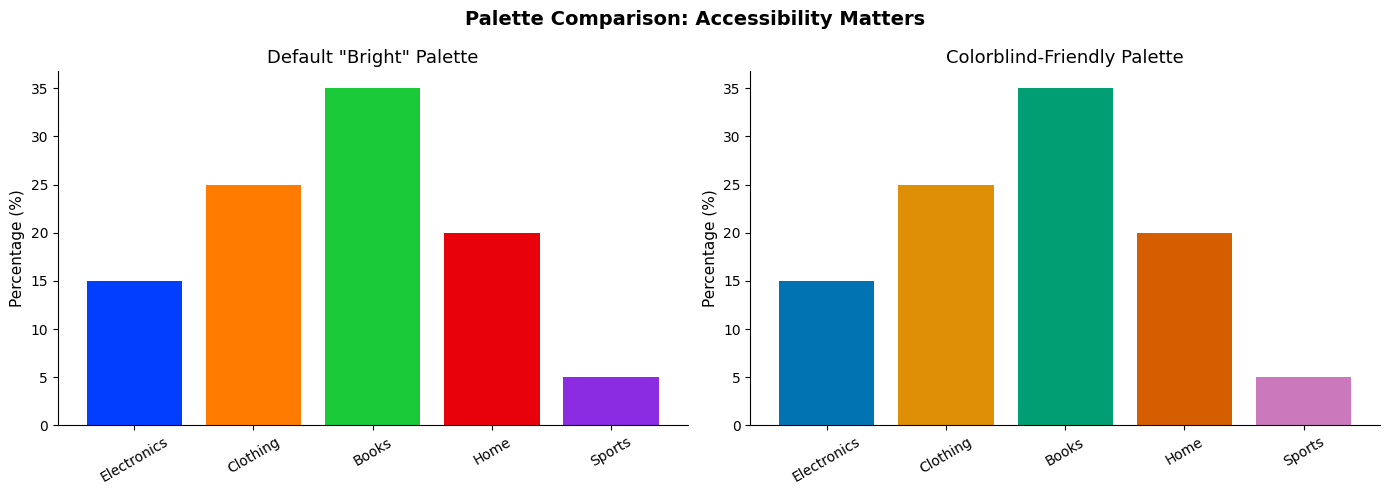

In [55]:
# Colorblind palette comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data = [15, 25, 35, 20, 5]
labels = ['Electronics', 'Clothing', 'Books', 'Home', 'Sports']

# Left: Default "bright" palette (problematic)
axes[0].bar(labels, data, color=sns.color_palette('bright'))
axes[0].set_title('Default "Bright" Palette', fontsize=13)
axes[0].set_ylabel('Percentage (%)', fontsize=11)

# Right: Colorblind-friendly palette
axes[1].bar(labels, data, color=sns.color_palette('colorblind'))
axes[1].set_title('Colorblind-Friendly Palette', fontsize=13)
axes[1].set_ylabel('Percentage (%)', fontsize=11)

# Clean up
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Palette Comparison: Accessibility Matters',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

<div style="background: #FEF9E7; color: gray; border-left: 5px solid #F39C12; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Warning:</strong> About 8% of men (1 in 12) have red-green color blindness. The "bright" palette includes red and green side by side — those two bars may appear nearly identical in color to these viewers.<br><br>
    <strong>Always use colorblind-friendly palettes.</strong> Seaborn's <code>'colorblind'</code> palette and Plotly's default color sequence are both designed to be accessible.
</div>

---

# Source: Data Storytelling & Interactive Dashboards Part 3.ipynb



<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px; margin-bottom:5px;">
    <h1 style="margin:0; color:white; font-size:28px;">Session 5.2: Practical Lab</h1>
    <h2 style="margin:5px 0 0 0; color:white; font-weight:normal; font-size:20px;">Data Storytelling & Interactive Dashboards</h2>
</div>

**Program:** Vishlesan i-Hub IIT Patna x Masai School — AIM (AI & Machine Learning)  
**Session ID:** 5.2 | **Week:** 5  
**Prerequisites:** Session 5.1 (Matplotlib & Seaborn Fundamentals)

---

## Learning Objectives

By the end of this lab, you will be able to:

1. Explain the Context-to-Insight-to-Action framework and distinguish between a data dump, a chart collection, and a data story
2. Apply chart selection principles and identify common chart crimes (misleading axes, chart junk, wrong chart type)
3. Create interactive visualizations using Plotly Express including line, bar, scatter, and animated bubble charts
4. Build a basic Streamlit web application that displays data, metrics, and interactive Plotly charts
5. Add interactive filter widgets to a Streamlit app and understand the reactive execution model
6. Design dashboard layouts using columns and sidebar, applying narrative flow principles (Summary-to-Trend-to-Breakdown-to-Detail)
7. Assemble a complete interactive E-commerce dashboard as a Streamlit application

In [56]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 3: Plotly Express — Interactive Charts</h2>
    <p style="margin:5px 0 0 0; font-size:14px;">From Static to Interactive — The Rosling Moment</p>
</div>

<div style="background: #EBF5FB; color: gray; border-left: 5px solid #3498DB; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Key Concept — Plotly Express:</strong><br><br>
    Plotly Express is a high-level API that creates <strong>interactive charts</strong> with zero extra code. Every chart includes:<br><br>
    • <strong>Hover tooltips</strong> — Move cursor over any data point to see exact values<br>
    • <strong>Zoom</strong> — Click and drag to zoom into any region<br>
    • <strong>Pan</strong> — Click and drag to scroll around<br>
    • <strong>Legend toggle</strong> — Click category names to show/hide<br>
    • <strong>Auto-ranging</strong> — Axes adjust automatically when you filter<br>
    • <strong>Toolbar</strong> — Download as PNG, reset axes, auto-scale<br><br>
    <strong>All of this is FREE — automatic with every Plotly Express chart.</strong>
</div>

### Demo 1: Line Chart — Life Expectancy Over Time

In [57]:
# Select 5 countries for a clean comparison
selected = gapminder[gapminder['country'].isin(
    ['India', 'China', 'Nigeria', 'USA', 'Japan']
)]

fig = px.line(
    selected,
    x='year',
    y='life_expectancy',
    color='country',
    title='Life Expectancy Over Time (2000-2020)',
    labels={
        'life_expectancy': 'Life Expectancy (years)',
        'year': 'Year'
    },
    markers=True
)

fig.show()

print("Try it:")
print("1. Hover over ANY point to see exact values")
print("2. Click a country name in the legend to hide/show it")
print("3. Double-click to reset the view")

Try it:
1. Hover over ANY point to see exact values
2. Click a country name in the legend to hide/show it
3. Double-click to reset the view


In [58]:
gapminder


,country,continent,year,life_expectancy,gdp_per_capita,population
0,India,Asia,2000,62.5,1900,1053
1,India,Asia,2005,64.0,2800,1131
2,India,Asia,2010,66.5,4500,1210
3,India,Asia,2015,68.3,6200,1310
4,India,Asia,2020,70.1,6500,1380
5,China,Asia,2000,71.4,3700,1267
6,China,Asia,2005,73.0,5500,1304
7,China,Asia,2010,75.0,9100,1341
8,China,Asia,2015,76.1,13400,1376
9,China,Asia,2020,77.1,16800,1412


In [59]:
gapminder["year"].unique()

array([2000, 2005, 2010, 2015, 2020])

### Demo 2: Horizontal Bar Chart — GDP by Country (2020)

In [60]:
# Filter to 2020 only and sort by GDP
data_2020 = gapminder[gapminder['year'] == 2020].sort_values('gdp_per_capita')

fig = px.bar(
    data_2020,
    x='gdp_per_capita',
    y='country',
    color='continent',
    orientation='h',
    title='GDP per Capita by Country (2020)',
    labels={
        'gdp_per_capita': 'GDP per Capita (USD)',
        'country': ''
    }
)

fig.show()

print("Notice:")
print("1. Sorted, horizontal, colored by continent")
print("2. Hover shows exact GDP value")
print("3. This took 6 lines of code — would be 15+ in Matplotlib")

Notice:
1. Sorted, horizontal, colored by continent
2. Hover shows exact GDP value
3. This took 6 lines of code — would be 15+ in Matplotlib


### Demo 3: THE ROSLING MOMENT — Animated Bubble Chart

<div style="background: #ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h3 style="margin:0; color:white;">Five Dimensions on One Chart</h3>
    <p style="margin:5px 0 0 0; font-size:14px;">x-axis = GDP per capita | y-axis = Life expectancy | Bubble size = Population | Bubble color = Continent | Animation = Year</p>
</div>

This is the chart that stunned the UN audience. Press Play and watch 20 years of global development unfold.

In [61]:
# THE ROSLING CHART: Five dimensions, one visualization
fig = px.scatter(
    gapminder,
    x='gdp_per_capita',
    y='life_expectancy',
    size='population',
    color='continent',
    hover_name='country',
    animation_frame='year',
    animation_group='country',
    size_max=60,
    range_x=[0, 70000],
    range_y=[40, 90],
    title='The Rosling Chart: Global Development (2000-2020)',
    labels={
        'gdp_per_capita': 'GDP per Capita (USD)',
        'life_expectancy': 'Life Expectancy (years)',
        'population': 'Population (millions)'
    }
)

fig.update_layout(
    xaxis_title='GDP per Capita (USD)',
    yaxis_title='Life Expectancy (years)',
    showlegend=True
)

fig.show()

print("Press PLAY to watch the world develop.")
print("")
print("Watch India and China move RIGHT (getting wealthier) and UP (living longer).")
print("Watch Nigeria barely move — stuck in the lower-left.")
print("The gap IS the story.")

Press PLAY to watch the world develop.

Watch India and China move RIGHT (getting wealthier) and UP (living longer).
Watch Nigeria barely move — stuck in the lower-left.
The gap IS the story.


<div style="background: #FEF9E7; color: gray; border-left: 5px solid #F39C12; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Critical Parameters:</strong><br><br>
    • <code>animation_frame='year'</code> — Creates the time slider. Each unique value becomes one frame.<br>
    • <code>animation_group='country'</code> — Tells Plotly which bubble is which across frames. Without this, bubbles redraw instead of moving smoothly.<br>
    • <code>size_max=60</code> — Caps maximum bubble size so India/China don't dominate the chart.<br>
    • <code>range_x=[0, 70000]</code>, <code>range_y=[40, 90]</code> — FIX axis ranges across all frames. Without this, axes auto-scale per frame and you can't compare positions across years.
</div>

### Demo 4: E-commerce Scatter Plot with Hover Data

In [62]:
# Create e-commerce dataset (same as Session 5.1)
np.random.seed(42)
n = 40
categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports']
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata']
payment_methods = ['UPI', 'Credit Card', 'COD', 'Debit Card', 'Net Banking']

base_prices = {
    'Electronics': 15000, 'Clothing': 1500,
    'Books': 500, 'Home & Kitchen': 3000,
    'Sports': 2000
}

cat_choices = np.random.choice(categories, n)
city_choices = np.random.choice(cities, n)
quantities = np.random.randint(1, 5, n)
unit_prices = np.array([
    base_prices[c] + np.random.randint(-500, 2000)
    for c in cat_choices
])
ratings = np.round(np.random.uniform(2.5, 5.0, n), 1)

ecommerce = pd.DataFrame({
    'order_id': [f'ORD{str(i).zfill(3)}' for i in range(1, n + 1)],
    'order_date': pd.date_range('2025-01-01', periods=n, freq='3D'),
    'product_category': cat_choices,
    'city': city_choices,
    'quantity': quantities,
    'unit_price': unit_prices,
    'total_amount': unit_prices * quantities,
    'payment_method': np.random.choice(payment_methods, n),
    'customer_rating': ratings
})

print(f"E-commerce dataset: {ecommerce.shape[0]} orders × {ecommerce.shape[1]} columns")

E-commerce dataset: 40 orders × 9 columns


In [63]:
# Interactive scatter: Price vs Rating with hover data
fig = px.scatter(
    ecommerce,
    x='unit_price',
    y='customer_rating',
    color='product_category',
    size='quantity',
    hover_data=['city', 'payment_method', 'total_amount'],
    title='Unit Price vs Customer Rating by Category',
    labels={
        'unit_price': 'Unit Price (INR)',
        'customer_rating': 'Customer Rating'
    }
)

fig.show()

print("Compare with Session 5.1:")
print("In the static Matplotlib scatter plot, you could see the point position.")
print("But you had NO IDEA which city, payment method, or total amount.")
print("That information was TRAPPED in the DataFrame.")
print("")
print("Now it's one hover away.")

Compare with Session 5.1:
In the static Matplotlib scatter plot, you could see the point position.
But you had NO IDEA which city, payment method, or total amount.
That information was TRAPPED in the DataFrame.

Now it's one hover away.


### Demo 5: HTML Export — Share Interactive Charts Anywhere

In [64]:
# Export the scatter chart as standalone HTML
fig.write_html('ecommerce_scatter.html')

print("Interactive chart saved as 'ecommerce_scatter.html'")
print("Open this file in any web browser — it works without Python!")
print("")
print("The HTML file is self-contained:")
print("• Includes all the data needed for the chart")
print("• Embeds the Plotly.js library (works offline)")
print("• Full interactivity: hover, zoom, pan, legend toggle")
print("")
print("Share it via email, Google Drive, Slack, or any file-sharing platform.")
print("The recipient does NOT need Python, Jupyter, or Plotly installed.")
print("Just a web browser.")

Interactive chart saved as 'ecommerce_scatter.html'
Open this file in any web browser — it works without Python!

The HTML file is self-contained:
• Includes all the data needed for the chart
• Embeds the Plotly.js library (works offline)
• Full interactivity: hover, zoom, pan, legend toggle

Share it via email, Google Drive, Slack, or any file-sharing platform.
The recipient does NOT need Python, Jupyter, or Plotly installed.
Just a web browser.


<div style="background: #EAFAF1; color: gray; border-left: 5px solid #2ECC71; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Best Practice:</strong><br><br>
    <strong>Matplotlib = Publication-quality static figures</strong> (research papers, reports)<br>
    <strong>Seaborn = Quick statistical exploration</strong> (boxplots, heatmaps, pairplots)<br>
    <strong>Plotly Express = Interactive dashboards and presentations</strong> (web apps, stakeholder reports)<br><br>
    You do NOT replace one with another — you use the right tool for the right purpose.
</div>

<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 4: Streamlit Fundamentals</h2>
    <p style="margin:5px 0 0 0; font-size:14px;">From Jupyter Notebooks to Web Applications</p>
</div>

<div style="background: #FEF9E7; color: gray; border-left: 5px solid #F39C12; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>IMPORTANT: Streamlit Cannot Run in Jupyter Notebooks</strong><br><br>
    Unlike the Plotly Express code above (which runs in Jupyter), Streamlit applications MUST be run as separate Python scripts.<br><br>
    <strong>Workflow:</strong><br>
    1. Copy the code blocks below into a new file called <code>app.py</code><br>
    2. Open your terminal and navigate to the directory containing <code>app.py</code><br>
    3. Run: <code>streamlit run app.py</code><br>
    4. A browser window will open showing your web app<br><br>
    <strong>The code cells below are for reference only — they will NOT execute in this notebook.</strong>
</div>

### Your First Streamlit App

Copy this code into a file called `app.py`:

```python
# app.py - Your First Streamlit Web Application
import streamlit as st
import pandas as pd

st.title("My First Streamlit App")
st.write("This is a live web application written entirely in Python!")

# Create a sample DataFrame
data = pd.DataFrame({
    'Product': ['Laptop', 'Phone', 'Tablet'],
    'Price': [50000, 30000, 20000]
})

st.dataframe(data)
st.metric(label="Total Revenue", value="₹1,00,000", delta="+15%")
```

**Expected Output:**
- A web page opens in your browser at `http://localhost:8501`
- You see a title: "My First Streamlit App"
- A table with 3 products and prices
- A metric card showing "Total Revenue: ₹1,00,000" with a green +15% delta

### Display Plotly Charts in Streamlit

Add this to your `app.py`:

```python
import streamlit as st
import plotly.express as px

# Create a Plotly chart
fig = px.bar(data, x='Product', y='Price', title='Product Prices')

# Display it in Streamlit
st.plotly_chart(fig)
```

**Expected Output:**
- An interactive Plotly bar chart appears in your Streamlit app
- All interactivity (hover, zoom, legend toggle) works in the browser

<div style="background: #EBF5FB; color: gray; border-left: 5px solid #3498DB; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Core Streamlit Display Functions:</strong><br><br>
    • <code>st.title()</code> — Main page title<br>
    • <code>st.write()</code> — Display text, DataFrames, or almost anything<br>
    • <code>st.dataframe()</code> — Display an interactive table<br>
    • <code>st.metric()</code> — Display KPI metric cards with optional delta<br>
    • <code>st.plotly_chart()</code> — Display a Plotly figure<br><br>
    <strong>Every time you save <code>app.py</code>, Streamlit detects the change and prompts to rerun.</strong>
</div>

<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 5: Interactive Filters & Layout</h2>
    <p style="margin:5px 0 0 0; font-size:14px;">Making Dashboards Interactive</p>
</div>

### Sidebar Filters

Add filter widgets to your `app.py`:

```python
import streamlit as st

# Sidebar filters
category = st.sidebar.selectbox("Select Category", ['Electronics', 'Clothing', 'Books'])
cities = st.sidebar.multiselect("Select Cities", ['Mumbai', 'Delhi', 'Bangalore'])
price_range = st.sidebar.slider("Price Range", 0, 100000, (10000, 50000))

st.write(f"You selected: {category}")
st.write(f"Cities: {cities}")
st.write(f"Price range: ₹{price_range[0]:,} - ₹{price_range[1]:,}")
```

**Expected Output:**
- A sidebar appears on the left with 3 filter controls
- Dropdown for category selection
- Multi-select for cities (can select multiple)
- Slider for price range (drag to adjust)
- The main page updates instantly when you change any filter

### Multi-Column Layout

Arrange content horizontally with `st.columns()`:

```python
col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Total Revenue", "₹5,00,000")

with col2:
    st.metric("Total Orders", "120")

with col3:
    st.metric("Avg Order Value", "₹4,167")
```

**Expected Output:**
- Three metric cards arranged horizontally in a single row
- Each card shows a label and value
- Professional KPI dashboard appearance

### Streamlit's Reactive Execution Model

<div style="background: #EBF5FB; color: gray; border-left: 5px solid #3498DB; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Key Concept — Reactive Execution:</strong><br><br>
    Every time a user changes ANY widget value (selectbox, slider, etc.), Streamlit re-runs your ENTIRE script from top to bottom. This means:<br><br>
    • Filters update automatically<br>
    • Charts recalculate with new filtered data<br>
    • Metrics reflect current filter selections<br>
    • NO "Submit" button needed — changes are instant<br><br>
    <strong>You write code as if it runs once. Streamlit makes it reactive.</strong>
</div>

<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 6: Dashboard Design Principles</h2>
    <p style="margin:5px 0 0 0; font-size:14px;">Professional Dashboard Narrative Flow</p>
</div>

### The Inverted Pyramid Structure

Professional dashboards follow a top-to-bottom narrative:

1. **SUMMARY (Top):** KPI metric cards — the 3-5 most important numbers. Total revenue, orders, conversion rate.
2. **TREND (Second row):** Line charts showing how KPIs change over time. Revenue trend, order volume trend.
3. **BREAKDOWN (Third row):** Bar charts, pie charts showing composition. Revenue by category, orders by city.
4. **DETAIL (Bottom):** Filtered data tables, scatter plots, drill-down views for analysts.

**The principle:** A VP should get the answer from the top row in 5 seconds. A manager should understand the trend in 30 seconds. An analyst can spend 15 minutes exploring the detail.

### Audience Types

- **Executive Dashboard:** Focus on Summary + Trend. Minimal detail. Big numbers, clear trends, 3-5 KPIs max.
- **Analyst Dashboard:** Include Breakdown + Detail. Interactive filters for deep exploration. Data tables at the bottom.

**Design for the VP first. Everything else is progressive detail.**

### Deployment Overview

- **Local:** `streamlit run dashboard.py` (runs on localhost:8501)
- **Sharing:** Streamlit Community Cloud (free tier, connect GitHub repo, auto-deploy)
  - Push your `dashboard.py` to a GitHub repo
  - Go to share.streamlit.io
  - Connect your repo → app deploys automatically
  - Get a public URL like `your-app-name.streamlit.app`

<div style="background: #EAFAF1; color: gray; border-left: 5px solid #2ECC71; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Best Practice:</strong><br><br>
    • <code>st.sidebar.X()</code> puts widgets in the sidebar<br>
    • <code>st.X()</code> puts them in the main area<br>
    • Use <code>st.columns()</code> for horizontal arrangement of metrics or charts<br>
    • Follow the inverted pyramid: Summary → Trend → Breakdown → Detail<br>
    • For executive dashboards, limit to 3-5 KPIs max<br>
</div>

<div style="background: linear-gradient(135deg, #ED1C24, #c0392b); color:white; padding:20px 30px; border-radius:10px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Part 7: Mini-Project — E-commerce Interactive Dashboard</h2>
    <p style="margin:8px 0 0 0; font-size:15px;">Complete Streamlit Application with Filters, KPIs, and Interactive Charts</p>
</div>

This complete dashboard combines everything from this session:
- Data storytelling (Context → Insight → Action)
- Plotly Express interactive charts
- Streamlit sidebar filters and reactive execution
- Professional dashboard narrative flow

**Copy the code below into `dashboard.py` and run `streamlit run dashboard.py`**

```python
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px

# Configure page
st.set_page_config(page_title="E-commerce Dashboard", layout="wide")

# Title
st.title("📊 E-commerce Performance Dashboard")

# Load data (recreate the e-commerce dataset)
np.random.seed(42)
n = 40
categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports']
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata']

ecommerce = pd.DataFrame({
    'order_id': [f'ORD{str(i).zfill(3)}' for i in range(1, n + 1)],
    'order_date': pd.date_range('2025-01-01', periods=n, freq='3D'),
    'product_category': np.random.choice(categories, n),
    'city': np.random.choice(cities, n),
    'quantity': np.random.randint(1, 5, n),
    'unit_price': np.random.randint(500, 50000, n),
    'customer_rating': np.round(np.random.uniform(2.5, 5.0, n), 1)
})
ecommerce['total_amount'] = ecommerce['unit_price'] * ecommerce['quantity']

# Sidebar filters
st.sidebar.header("Filters")
selected_categories = st.sidebar.multiselect(
    "Product Category",
    options=categories,
    default=categories
)

selected_cities = st.sidebar.multiselect(
    "City",
    options=cities,
    default=cities
)

date_range = st.sidebar.date_input(
    "Date Range",
    value=(ecommerce['order_date'].min(), ecommerce['order_date'].max())
)

# Filter data
filtered_df = ecommerce[
    (ecommerce['product_category'].isin(selected_categories)) &
    (ecommerce['city'].isin(selected_cities)) &
    (ecommerce['order_date'] >= pd.to_datetime(date_range[0])) &
    (ecommerce['order_date'] <= pd.to_datetime(date_range[1]))
]

# KPI Metrics (Summary)
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Total Revenue", f"₹{filtered_df['total_amount'].sum():,.0f}")

with col2:
    st.metric("Total Orders", f"{len(filtered_df)}")

with col3:
    st.metric("Avg Order Value", f"₹{filtered_df['total_amount'].mean():,.0f}")

with col4:
    st.metric("Avg Rating", f"{filtered_df['customer_rating'].mean():.1f} / 5.0")

# Trend Chart
st.subheader("📈 Monthly Revenue Trend")
monthly_revenue = filtered_df.groupby(filtered_df['order_date'].dt.to_period('M'))['total_amount'].sum().reset_index()
monthly_revenue['order_date'] = monthly_revenue['order_date'].astype(str)

fig_trend = px.line(
    monthly_revenue,
    x='order_date',
    y='total_amount',
    title='Revenue Over Time',
    labels={'order_date': 'Month', 'total_amount': 'Revenue (INR)'},
    markers=True
)
st.plotly_chart(fig_trend, use_container_width=True)

# Breakdown Charts
col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 Revenue by Category")
    category_revenue = filtered_df.groupby('product_category')['total_amount'].sum().sort_values()
    fig_category = px.bar(
        category_revenue,
        x=category_revenue.values,
        y=category_revenue.index,
        orientation='h',
        title='Revenue by Product Category',
        labels={'x': 'Revenue (INR)', 'y': 'Category'}
    )
    st.plotly_chart(fig_category, use_container_width=True)

with col2:
    st.subheader("🔍 Price vs Rating")
    fig_scatter = px.scatter(
        filtered_df,
        x='unit_price',
        y='customer_rating',
        size='quantity',
        color='product_category',
        hover_data=['city', 'total_amount'],
        title='Unit Price vs Customer Rating',
        labels={'unit_price': 'Unit Price (INR)', 'customer_rating': 'Rating'}
    )
    st.plotly_chart(fig_scatter, use_container_width=True)

# Detail: Raw Data Table
st.subheader("📋 Filtered Data")
st.dataframe(filtered_df, use_container_width=True)
```

### Expected Output

When you run `streamlit run dashboard.py`, you will see:

1. **Title:** "E-commerce Performance Dashboard"
2. **Sidebar (left):** 3 filter controls (category multiselect, city multiselect, date range)
3. **Top Row (Summary):** 4 KPI metric cards (total revenue, total orders, avg order value, avg rating)
4. **Second Row (Trend):** Monthly revenue line chart
5. **Third Row (Breakdown):** Two-column layout:
   - Left: Revenue by category horizontal bar chart
   - Right: Price vs rating scatter plot
6. **Bottom Row (Detail):** Full filtered data table

**All charts and metrics update reactively when you change any filter in the sidebar.**

<div style="background: #EBF5FB; color: gray; border-left: 5px solid #3498DB; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Mini-Project Key Features:</strong><br><br>
    • <code>st.set_page_config(layout='wide')</code> uses full browser width<br>
    • <code>use_container_width=True</code> makes charts responsive<br>
    • Sidebar filters with multiselect and date_input<br>
    • Four-column KPI metrics at the top (Summary)<br>
    • Monthly revenue line chart (Trend)<br>
    • Two-column layout for breakdown charts<br>
    • Data table at the bottom (Detail)<br><br>
    <strong>This is the professional dashboard pattern used in industry.</strong>
</div>

<div style="background: #FEF9E7; color: black; border-left: 5px solid #F39C12; padding: 12px 15px; margin: 10px 0; border-radius: 4px;">
    <strong>Warning:</strong> Filters only work if ALL selected options have data. If you clear all categories in the multiselect, <code>filtered_df</code> becomes empty and the dashboard breaks.<br><br>
    <strong>Production fix:</strong> Add validation to ensure at least one option is selected in each filter.
</div>

---

<div style="background-color:#ED1C24; color:white; padding:12px 20px; border-radius:8px; margin:10px 0;">
    <h2 style="margin:0; color:white;">Session Summary</h2>
</div>

### Key Learnings from Session 5.2

1. **DATA STORYTELLING:** Three levels — Data Dump (nobody reads), Chart Collection (no narrative), Data Story (Context→Insight→Action)
2. **CHART SELECTION:** Match the analytical question to the chart type. Trend→Line, Comparison→Bar, Correlation→Scatter, Distribution→Histogram
3. **CHART REDESIGN:** Sort by value, use horizontal orientation for 5+ categories, single color + accent, remove chart junk, add value labels, insight headline
4. **COLOR THEORY:** Use colorblind-friendly palettes. Avoid red-green combinations (8% of men cannot distinguish)
5. **PLOTLY EXPRESS:** Interactive by default — hover, zoom, pan, legend toggle all free. One line of code creates complete charts
6. **ANIMATED CHARTS:** `animation_frame` + `animation_group` creates the Rosling effect. Fix axis ranges across frames with `range_x`, `range_y`
7. **HTML EXPORT:** `fig.write_html()` creates standalone interactive files that work in any browser without Python
8. **STREAMLIT:** Turns Python scripts into web apps. Reactive execution model — entire script reruns when any widget changes
9. **DASHBOARD DESIGN:** Inverted pyramid — Summary (KPIs) → Trend (line charts) → Breakdown (bar charts) → Detail (tables, scatter)
10. **THE COMPLETE PIPELINE:** From raw data to interactive web dashboard — all in Python

**You now have the complete toolkit: static charts (Matplotlib/Seaborn), interactive charts (Plotly Express), and web dashboards (Streamlit).**